In [ ]:
class AdvancedCalculusFramework:
    """
    Advanced calculus framework demonstrating sophisticated differential and integral calculus
    with graduate-level mathematical rigor and comprehensive ML applications
    """
    
    def __init__(self):
        """Initialize advanced calculus computation framework"""
        import numpy as np
        import scipy.optimize as opt
        import scipy.integrate as integrate
        import scipy.special as special
        import matplotlib.pyplot as plt
        from sklearn.gaussian_process import GaussianProcessRegressor
        from sklearn.gaussian_process.kernels import RBF, Matern
        import sympy as sp
        import time
        import warnings
        warnings.filterwarnings('ignore')
        
        self.np = np
        self.opt = opt
        self.integrate = integrate
        self.special = special
        self.plt = plt
        self.sp = sp
        self.random_state = 42
        np.random.seed(self.random_state)
        
        # Store modules for use in methods
        self.modules = {
            'GaussianProcessRegressor': GaussianProcessRegressor,
            'RBF': RBF,
            'Matern': Matern,
            'time': time
        }
        
    def demonstrate_automatic_differentiation(self):
        """Advanced automatic differentiation with forward and reverse mode"""
        print("=== Automatic Differentiation: Forward and Reverse Mode ===\n")
        
        # 1. Forward Mode Automatic Differentiation
        print("=== 1. Forward Mode AD Implementation ===")
        
        class DualNumber:
            """Dual number class for forward mode AD"""
            def __init__(self, real, dual=0.0):
                self.real = real
                self.dual = dual
                
            def __add__(self, other):
                if isinstance(other, DualNumber):
                    return DualNumber(self.real + other.real, self.dual + other.dual)
                return DualNumber(self.real + other, self.dual)
                
            def __radd__(self, other):
                return self.__add__(other)
                
            def __mul__(self, other):
                if isinstance(other, DualNumber):
                    return DualNumber(self.real * other.real, 
                                    self.real * other.dual + self.dual * other.real)
                return DualNumber(self.real * other, self.dual * other)
                
            def __rmul__(self, other):
                return self.__mul__(other)
                
            def __pow__(self, n):
                if isinstance(n, (int, float)):
                    return DualNumber(self.real ** n, n * (self.real ** (n-1)) * self.dual)
                raise NotImplementedError("Power with dual number exponent not implemented")
                
            def exp(self):
                exp_real = np.exp(self.real)
                return DualNumber(exp_real, exp_real * self.dual)
                
            def sin(self):
                return DualNumber(np.sin(self.real), np.cos(self.real) * self.dual)
                
            def cos(self):
                return DualNumber(np.cos(self.real), -np.sin(self.real) * self.dual)
                
            def __repr__(self):
                return f"DualNumber({self.real:.6f}, {self.dual:.6f})"
        
        # Test forward mode AD
        def test_function_forward(x):
            """Test function: f(x) = x³ + 2x² - 5x + 3"""
            return x**3 + 2*x**2 - 5*x + 3
            
        def test_function_derivative(x):
            """Analytical derivative: f'(x) = 3x² + 4x - 5"""
            return 3*x**2 + 4*x - 5
        
        x_val = 2.5
        x_dual = DualNumber(x_val, 1.0)  # Set dual part to 1 for derivative
        
        result = test_function_forward(x_dual)
        analytical_derivative = test_function_derivative(x_val)
        
        print(f"Function value at x={x_val}: {result.real:.6f}")
        print(f"Forward mode derivative: {result.dual:.6f}")
        print(f"Analytical derivative: {analytical_derivative:.6f}")
        print(f"Error: {abs(result.dual - analytical_derivative):.2e}\n")
        
        # 2. Reverse Mode AD (Backpropagation)
        print("=== 2. Reverse Mode AD Implementation ===")
        
        class Variable:
            """Variable class for reverse mode AD"""
            def __init__(self, value, grad=0.0, children=None, operation=None):
                self.value = value
                self.grad = grad
                self.children = children or []
                self.operation = operation
                
            def backward(self):
                """Compute gradients via backpropagation"""
                if self.operation == 'add':
                    self.children[0].grad += self.grad
                    self.children[1].grad += self.grad
                elif self.operation == 'mul':
                    self.children[0].grad += self.grad * self.children[1].value
                    self.children[1].grad += self.grad * self.children[0].value
                elif self.operation == 'pow':
                    base, exp = self.children[0], self.children[1]
                    base.grad += self.grad * exp.value * (base.value ** (exp.value - 1))
                elif self.operation == 'exp':
                    self.children[0].grad += self.grad * np.exp(self.children[0].value)
                elif self.operation == 'sin':
                    self.children[0].grad += self.grad * np.cos(self.children[0].value)
                
                # Recursively backpropagate
                for child in self.children:
                    if hasattr(child, 'backward'):
                        child.backward()
                        
            def __add__(self, other):
                if not isinstance(other, Variable):
                    other = Variable(other)
                result = Variable(self.value + other.value, children=[self, other], operation='add')
                return result
                
            def __mul__(self, other):
                if not isinstance(other, Variable):
                    other = Variable(other)
                result = Variable(self.value * other.value, children=[self, other], operation='mul')
                return result
                
            def __pow__(self, exp):
                if not isinstance(exp, Variable):
                    exp = Variable(exp)
                result = Variable(self.value ** exp.value, children=[self, exp], operation='pow')
                return result
                
            def exp(self):
                result = Variable(np.exp(self.value), children=[self], operation='exp')
                return result
                
            def sin(self):
                result = Variable(np.sin(self.value), children=[self], operation='sin')
                return result
        
        # Test reverse mode AD
        def test_function_reverse(x):
            """Same test function for reverse mode"""
            return x**3 + x*2*x - x*5 + 3
        
        x_var = Variable(x_val)
        result_var = test_function_reverse(x_var)
        
        # Start backpropagation
        result_var.grad = 1.0  # Set output gradient to 1
        result_var.backward()
        
        print(f"Function value at x={x_val}: {result_var.value:.6f}")
        print(f"Reverse mode derivative: {x_var.grad:.6f}")
        print(f"Analytical derivative: {analytical_derivative:.6f}")
        print(f"Error: {abs(x_var.grad - analytical_derivative):.2e}\n")
        
        # 3. Gradient of Multivariate Functions
        print("=== 3. Multivariate Function Gradients ===")
        
        def rosenbrock_function(vars_list):
            """Rosenbrock function: f(x,y) = (1-x)² + 100(y-x²)²"""
            x, y = vars_list[0], vars_list[1]
            term1 = (1 - x) * (1 - x)
            term2 = (y - x*x) * (y - x*x) * 100
            return term1 + term2
        
        # Test point
        x_test, y_test = 0.5, 0.8
        vars_test = [Variable(x_test), Variable(y_test)]
        
        result = rosenbrock_function(vars_test)
        result.grad = 1.0
        result.backward()
        
        # Analytical gradients
        def rosenbrock_gradient(x, y):
            dx = -2*(1-x) + 400*x*(x**2 - y)
            dy = 200*(y - x**2)
            return dx, dy
        
        analytical_grad = rosenbrock_gradient(x_test, y_test)
        computed_grad = (vars_test[0].grad, vars_test[1].grad)
        
        print(f"Function value: {result.value:.6f}")
        print(f"Computed gradient: ({computed_grad[0]:.6f}, {computed_grad[1]:.6f})")
        print(f"Analytical gradient: ({analytical_grad[0]:.6f}, {analytical_grad[1]:.6f})")
        print(f"Gradient error: {np.linalg.norm(np.array(computed_grad) - np.array(analytical_grad)):.2e}")
        
        return {
            'forward_mode_derivative': result.dual,
            'reverse_mode_derivative': x_var.grad,
            'multivariate_gradient': computed_grad,
            'analytical_gradient': analytical_grad
        }
        
    def demonstrate_numerical_integration(self):
        """Advanced numerical integration methods with error analysis"""
        print("=== Advanced Numerical Integration: Methods and Applications ===\n")
        
        # 1. Adaptive Quadrature Methods
        print("=== 1. Adaptive Quadrature Analysis ===")
        
        def test_integrand_1(x):
            """Smooth function: f(x) = e^(-x²) * cos(x)"""
            return np.exp(-x**2) * np.cos(x)
            
        def test_integrand_2(x):
            """Oscillatory function: f(x) = sin(10x) / (1 + x²)"""
            return np.sin(10*x) / (1 + x**2)
            
        def test_integrand_3(x):
            """Function with singularity: f(x) = x^(-0.3) * log(x+1)"""
            return np.where(x > 0, x**(-0.3) * np.log(x + 1), 0)
        
        integration_limits = [(0, 2), (-2, 2), (1e-6, 1)]
        test_functions = [test_integrand_1, test_integrand_2, test_integrand_3]
        function_names = ["Gaussian-Cosine", "Oscillatory", "Near-singular"]
        
        print("Adaptive quadrature comparison:")
        for i, (func, limits, name) in enumerate(zip(test_functions, integration_limits, function_names)):
            print(f"\n{name} function on [{limits[0]}, {limits[1]}]:")
            
            # Scipy adaptive quadrature
            result_adaptive, error_estimate = self.integrate.quad(func, limits[0], limits[1])
            
            # Fixed-step methods for comparison
            n_points = 1000
            x_points = np.linspace(limits[0], limits[1], n_points)
            y_points = func(x_points)
            
            # Trapezoidal rule
            h = (limits[1] - limits[0]) / (n_points - 1)
            trap_result = h * (0.5*y_points[0] + np.sum(y_points[1:-1]) + 0.5*y_points[-1])
            
            # Simpson's rule (requires odd number of points)
            if n_points % 2 == 0:
                n_simpson = n_points - 1
                x_simpson = np.linspace(limits[0], limits[1], n_simpson)
                y_simpson = func(x_simpson)
            else:
                x_simpson, y_simpson = x_points, y_points
                
            h_simpson = (limits[1] - limits[0]) / (len(x_simpson) - 1)
            simpson_result = h_simpson/3 * (y_simpson[0] + 4*np.sum(y_simpson[1::2]) + 
                                          2*np.sum(y_simpson[2:-1:2]) + y_simpson[-1])
            
            print(f"  Adaptive quad: {result_adaptive:.8f} ± {error_estimate:.2e}")
            print(f"  Trapezoidal:   {trap_result:.8f}")
            print(f"  Simpson's:     {simpson_result:.8f}")
            
            # Error analysis (using adaptive as reference)
            trap_error = abs(trap_result - result_adaptive)
            simpson_error = abs(simpson_result - result_adaptive)
            print(f"  Trap error:    {trap_error:.2e}")
            print(f"  Simpson error: {simpson_error:.2e}")
        
        # 2. Monte Carlo Integration
        print(f"\n=== 2. Monte Carlo Integration ===")
        
        def monte_carlo_integration(func, bounds, n_samples=100000):
            """Monte Carlo integration for multidimensional integrals"""
            dim = len(bounds)
            
            # Generate random samples
            samples = np.random.uniform(size=(n_samples, dim))
            
            # Scale to integration bounds
            for i, (a, b) in enumerate(bounds):
                samples[:, i] = a + (b - a) * samples[:, i]
            
            # Evaluate function
            if dim == 1:
                func_values = func(samples[:, 0])
            else:
                func_values = np.array([func(sample) for sample in samples])
            
            # Compute integral
            volume = np.prod([b - a for a, b in bounds])
            integral = volume * np.mean(func_values)
            error_estimate = volume * np.std(func_values) / np.sqrt(n_samples)
            
            return integral, error_estimate
        
        # Test 1D Monte Carlo
        mc_result_1d, mc_error_1d = monte_carlo_integration(test_integrand_1, [(0, 2)])
        analytical_1d, _ = self.integrate.quad(test_integrand_1, 0, 2)
        
        print(f"1D Monte Carlo vs Analytical:")
        print(f"  Monte Carlo: {mc_result_1d:.6f} ± {mc_error_1d:.3f}")
        print(f"  Analytical:  {analytical_1d:.6f}")
        print(f"  Error:       {abs(mc_result_1d - analytical_1d):.3f}")
        
        # Test 2D Monte Carlo
        def test_2d_function(point):
            """2D test function: f(x,y) = exp(-(x²+y²)) * sin(x*y)"""
            x, y = point[0], point[1]
            return np.exp(-(x**2 + y**2)) * np.sin(x * y)
        
        mc_result_2d, mc_error_2d = monte_carlo_integration(test_2d_function, [(-2, 2), (-2, 2)])
        
        print(f"\n2D Monte Carlo integration:")
        print(f"  Result: {mc_result_2d:.6f} ± {mc_error_2d:.3f}")
        print(f"  Domain: [-2,2] × [-2,2]")
        
        # 3. Gaussian Quadrature
        print(f"\n=== 3. Gaussian Quadrature Methods ===")
        
        def gaussian_quadrature_demo():
            """Demonstrate Gaussian quadrature accuracy"""
            
            # Test function: polynomial
            def polynomial(x):
                return 2*x**4 - 3*x**3 + x**2 - 2*x + 1
            
            # Analytical integral from -1 to 1
            analytical = self.integrate.quad(polynomial, -1, 1)[0]
            
            # Gaussian quadrature with different orders
            orders = [2, 3, 4, 5, 8]
            
            print("Gaussian quadrature for polynomial integration [-1, 1]:")
            print(f"Analytical result: {analytical:.10f}")
            
            for order in orders:
                # Get Gauss-Legendre points and weights
                points, weights = np.polynomial.legendre.leggauss(order)
                
                # Compute integral
                gauss_result = np.sum(weights * polynomial(points))
                error = abs(gauss_result - analytical)
                
                print(f"  Order {order:2d}: {gauss_result:.10f}, error: {error:.2e}")
            
            # Transform to arbitrary interval [a, b]
            a, b = 0, 3
            def transformed_polynomial(x):
                # Transform from [a,b] to [-1,1]: t = 2(x-a)/(b-a) - 1
                return polynomial(2*(x-a)/(b-a) - 1)
            
            analytical_transformed = self.integrate.quad(transformed_polynomial, a, b)[0]
            
            print(f"\nTransformed to [{a}, {b}]:")
            print(f"Analytical result: {analytical_transformed:.10f}")
            
            # Gauss-Legendre on transformed interval
            points_unit, weights_unit = np.polynomial.legendre.leggauss(5)
            # Transform points from [-1,1] to [a,b]
            points_transformed = 0.5 * (b - a) * points_unit + 0.5 * (b + a)
            weights_transformed = 0.5 * (b - a) * weights_unit
            
            gauss_transformed = np.sum(weights_transformed * transformed_polynomial(points_transformed))
            error_transformed = abs(gauss_transformed - analytical_transformed)
            
            print(f"  Gauss-5: {gauss_transformed:.10f}, error: {error_transformed:.2e}")
        
        gaussian_quadrature_demo()
        
        return {
            'adaptive_results': [result_adaptive],
            'monte_carlo_1d': mc_result_1d,
            'monte_carlo_2d': mc_result_2d,
            'gaussian_accuracy': error_transformed
        }
        
    def demonstrate_differential_equations(self):
        """Advanced ODE/PDE solving with applications to ML"""
        print("=== Differential Equations: Advanced Numerical Methods ===\n")
        
        # 1. Stiff ODE Systems
        print("=== 1. Stiff ODE Systems ===")
        
        def stiff_system(t, y):
            """Van der Pol oscillator (stiff for large μ)"""
            mu = 20  # Stiffness parameter
            dydt = np.zeros_like(y)
            dydt[0] = y[1]
            dydt[1] = mu * (1 - y[0]**2) * y[1] - y[0]
            return dydt
        
        # Initial conditions
        y0 = [2.0, 0.0]
        t_span = (0, 20)
        t_eval = np.linspace(0, 20, 1000)
        
        # Solve with different methods
        methods = ['RK45', 'RK23', 'Radau', 'BDF']
        solutions = {}
        
        print("Stiff Van der Pol oscillator (μ=20):")
        for method in methods:
            start_time = self.modules['time'].time()
            try:
                sol = self.integrate.solve_ivp(stiff_system, t_span, y0, method=method, 
                                             t_eval=t_eval, rtol=1e-8, atol=1e-10)
                solve_time = self.modules['time'].time() - start_time
                solutions[method] = sol
                
                print(f"  {method:6s}: {sol.nfev:4d} function evals, {solve_time:.3f}s, "
                      f"success: {sol.success}")
            except Exception as e:
                print(f"  {method:6s}: Failed - {str(e)}")
        
        # Energy conservation analysis
        if 'Radau' in solutions:
            sol = solutions['Radau']
            energy = 0.5 * (sol.y[0]**2 + sol.y[1]**2)  # Approximate energy
            energy_drift = np.std(energy) / np.mean(energy)
            print(f"  Energy conservation (relative std): {energy_drift:.2e}")
        
        # 2. Neural ODE Implementation
        print(f"\n=== 2. Neural ODE Implementation ===")
        
        class SimpleNeuralODE:
            """Simplified Neural ODE implementation"""
            
            def __init__(self, hidden_dim=20):
                self.hidden_dim = hidden_dim
                # Simple neural network weights
                np.random.seed(42)
                self.W1 = np.random.randn(hidden_dim, 2) * 0.1
                self.b1 = np.random.randn(hidden_dim) * 0.1
                self.W2 = np.random.randn(2, hidden_dim) * 0.1
                self.b2 = np.random.randn(2) * 0.1
                
            def neural_network(self, t, y):
                """Neural network dynamics"""
                # Forward pass: y -> hidden -> output
                hidden = np.tanh(self.W1 @ y + self.b1)
                output = self.W2 @ hidden + self.b2
                return output
            
            def forward(self, y0, t_span, t_eval):
                """Forward pass through Neural ODE"""
                sol = self.integrate.solve_ivp(self.neural_network, t_span, y0, 
                                             t_eval=t_eval, method='RK45')
                return sol.y.T  # Return as (time, features)
        
        # Test Neural ODE
        neural_ode = SimpleNeuralODE()
        neural_ode.integrate = self.integrate  # Provide integrate module
        
        y0_neural = np.array([1.0, 0.5])
        t_span_neural = (0, 2)
        t_eval_neural = np.linspace(0, 2, 100)
        
        trajectory = neural_ode.forward(y0_neural, t_span_neural, t_eval_neural)
        
        print(f"Neural ODE trajectory:")
        print(f"  Initial state: {y0_neural}")
        print(f"  Final state: {trajectory[-1]}")
        print(f"  Trajectory length: {len(trajectory)} points")
        
        # Compute some trajectory statistics
        displacement = np.linalg.norm(trajectory[-1] - trajectory[0])
        path_length = np.sum([np.linalg.norm(trajectory[i+1] - trajectory[i]) 
                             for i in range(len(trajectory)-1)])
        
        print(f"  Net displacement: {displacement:.4f}")
        print(f"  Total path length: {path_length:.4f}")
        
        # 3. PDE Solving: Heat Equation
        print(f"\n=== 3. PDE Solving: Heat Equation ===")
        
        def solve_heat_equation():
            """Solve 1D heat equation using finite differences"""
            # Parameters
            L = 1.0          # Domain length
            T = 0.1          # Final time
            alpha = 0.01     # Thermal diffusivity
            
            # Discretization
            nx = 50          # Spatial points
            nt = 1000        # Time steps
            
            dx = L / (nx - 1)
            dt = T / nt
            
            # Stability check (CFL condition)
            r = alpha * dt / dx**2
            print(f"Heat equation solution:")
            print(f"  Grid: {nx} × {nt}, r = αΔt/Δx² = {r:.3f}")
            
            if r > 0.5:
                print(f"  Warning: r > 0.5, solution may be unstable!")
            
            # Initial condition: Gaussian pulse
            x = np.linspace(0, L, nx)
            u = np.exp(-200 * (x - 0.5)**2)  # Initial temperature distribution
            u_initial = u.copy()
            
            # Boundary conditions (Dirichlet: u=0 at boundaries)
            u[0] = u[-1] = 0
            
            # Time stepping (explicit finite difference)
            for n in range(nt):
                u_new = u.copy()
                for i in range(1, nx-1):
                    u_new[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])
                u = u_new
                u[0] = u[-1] = 0  # Enforce boundary conditions
            
            # Analytical solution for comparison (approximate)
            t_final = T
            u_analytical = np.exp(-200 * (x - 0.5)**2) * np.exp(-200 * 4 * alpha * t_final)
            
            # Error analysis
            l2_error = np.sqrt(np.sum((u - u_analytical)**2) * dx)
            max_error = np.max(np.abs(u - u_analytical))
            
            print(f"  L2 error: {l2_error:.6f}")
            print(f"  Max error: {max_error:.6f}")
            print(f"  Initial max temp: {np.max(u_initial):.6f}")
            print(f"  Final max temp: {np.max(u):.6f}")
            
            return x, u, u_analytical, u_initial
        
        x_heat, u_final, u_analytical, u_initial = solve_heat_equation()
        
        # 4. Gradient Flow and Optimization
        print(f"\n=== 4. Gradient Flow for Optimization ===")
        
        def gradient_flow_optimization():
            """Solve optimization via gradient flow ODE"""
            
            # Objective function: Rosenbrock
            def rosenbrock(xy):
                x, y = xy[0], xy[1]
                return (1 - x)**2 + 100*(y - x**2)**2
            
            def rosenbrock_grad(xy):
                x, y = xy[0], xy[1]
                dx = -2*(1 - x) + 400*x*(x**2 - y)
                dy = 200*(y - x**2)
                return np.array([dx, dy])
            
            # Gradient flow: dx/dt = -∇f(x)
            def gradient_flow(t, xy):
                return -rosenbrock_grad(xy)
            
            # Starting point
            xy0 = np.array([0.0, 0.0])
            t_span = (0, 10)
            t_eval = np.linspace(0, 10, 1000)
            
            # Solve gradient flow
            sol = self.integrate.solve_ivp(gradient_flow, t_span, xy0, t_eval=t_eval)
            
            # Final point
            xy_final = sol.y[:, -1]
            
            # Objective values
            obj_initial = rosenbrock(xy0)
            obj_final = rosenbrock(xy_final)
            
            print(f"Gradient flow optimization:")
            print(f"  Initial point: ({xy0[0]:.4f}, {xy0[1]:.4f})")
            print(f"  Final point: ({xy_final[0]:.4f}, {xy_final[1]:.4f})")
            print(f"  Initial objective: {obj_initial:.6f}")
            print(f"  Final objective: {obj_final:.6f}")
            print(f"  Improvement: {obj_initial - obj_final:.6f}")
            print(f"  Distance to optimum: {np.linalg.norm(xy_final - np.array([1, 1])):.6f}")
            
            return sol
        
        gradient_sol = gradient_flow_optimization()
        
        return {
            'stiff_solutions': len(solutions),
            'neural_ode_displacement': displacement,
            'heat_equation_error': l2_error,
            'gradient_flow_improvement': gradient_sol.y[0, -1]
        }

framework = AdvancedCalculusFramework()

# Demonstrate all calculus capabilities
print("🔬 ADVANCED CALCULUS COMPUTATIONAL FRAMEWORK")
print("=" * 60)

results1 = framework.demonstrate_automatic_differentiation()
print("\n" + "="*60 + "\n")

results2 = framework.demonstrate_numerical_integration()
print("\n" + "="*60 + "\n")

results3 = framework.demonstrate_differential_equations()
print("\n" + "="*60)
print("✅ CALCULUS FRAMEWORK COMPLETE")

In [ ]:
# Comprehensive Advanced Calculus Implementation: Theoretical Concepts in Practice

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sympy as sp
from sympy import symbols, diff, limit, oo, sin, cos, exp, log, pi, sqrt, tanh, E
from scipy.optimize import minimize, minimize_scalar, fsolve
from scipy.special import expit  # sigmoid function
import seaborn as sns
from sklearn.datasets import make_regression, make_classification
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class AdvancedCalculusAnalysis:
    """
    Comprehensive implementation demonstrating advanced calculus concepts
    with applications to optimization theory and machine learning
    """
    
    def __init__(self):
        """Initialize the calculus analysis framework"""
        self.random_state = 42
        np.random.seed(self.random_state)
        
    def demonstrate_limit_theory_epsilon_delta(self):
        """Demonstrate rigorous ε-δ limit theory with computational verification"""
        print("=== Advanced Limit Theory: ε-δ Definitions and Computational Verification ===\n")
        
        def epsilon_delta_verification(func, limit_point, limit_value, epsilon, max_delta=1.0, num_points=1000):
            """
            Verify ε-δ definition of limits computationally
            Find largest δ such that |f(x) - L| < ε when 0 < |x - c| < δ
            """
            deltas = np.logspace(-6, np.log10(max_delta), num_points)
            valid_deltas = []
            
            for delta in deltas:
                # Test points in the δ-neighborhood
                test_points = np.random.uniform(limit_point - delta, limit_point + delta, 100)
                test_points = test_points[test_points != limit_point]  # Remove limit point itself
                
                if len(test_points) == 0:
                    continue
                    
                function_values = func(test_points)
                errors = np.abs(function_values - limit_value)
                
                if np.all(errors < epsilon):
                    valid_deltas.append(delta)
            
            return max(valid_deltas) if valid_deltas else 0
        
        # Example 1: Standard limit lim(x->2) x^2 = 4
        def quadratic(x):
            return x**2
        
        limit_point = 2.0
        limit_value = 4.0
        epsilons = [1.0, 0.1, 0.01, 0.001]
        
        print("=== Example 1: lim(x→2) x² = 4 ===")
        print("ε\t\tδ (computed)\tδ (theoretical)")
        print("-" * 45)
        
        for eps in epsilons:
            computed_delta = epsilon_delta_verification(quadratic, limit_point, limit_value, eps)
            # Theoretical: |x² - 4| = |x-2||x+2| < ε
            # For x near 2, |x+2| ≈ 4, so we need |x-2| < ε/4
            theoretical_delta = eps / 4
            
            print(f"{eps:8.3f}\t{computed_delta:8.6f}\t{theoretical_delta:8.6f}")
        
        # Example 2: Sigmoid activation function limit behavior
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))
        
        print(f"\n=== Example 2: Sigmoid Function Limits ===")
        
        # Limit as x → ∞
        x_large = np.linspace(5, 20, 100)
        sigmoid_large = sigmoid(x_large)
        
        print(f"lim(x→∞) σ(x) ≈ {sigmoid_large[-1]:.8f} (theoretical: 1.0)")
        print(f"Error: {abs(sigmoid_large[-1] - 1.0):.2e}")
        
        # Limit as x → -∞
        x_small = np.linspace(-20, -5, 100)
        sigmoid_small = sigmoid(x_small)
        
        print(f"lim(x→-∞) σ(x) ≈ {sigmoid_small[0]:.8f} (theoretical: 0.0)")
        print(f"Error: {abs(sigmoid_small[0] - 0.0):.2e}")
        
        # Example 3: ReLU function discontinuity analysis
        def relu(x):
            return np.maximum(0, x)
        
        def relu_derivative_approx(x, h=1e-6):
            """Approximate derivative using finite differences"""
            return (relu(x + h) - relu(x - h)) / (2 * h)
        
        print(f"\n=== Example 3: ReLU Discontinuity Analysis ===")
        
        x_values = [-0.1, -0.01, 0.0, 0.01, 0.1]
        
        print("x\t\tReLU(x)\t\tApprox Derivative")
        print("-" * 40)
        
        for x in x_values:
            relu_val = relu(x)
            if x == 0:
                deriv_approx = "undefined (discontinuous)"
            else:
                deriv_approx = f"{relu_derivative_approx(x):.6f}"
            
            print(f"{x:8.2f}\t{relu_val:8.6f}\t{deriv_approx}")
        
        # Visualization of limit concepts
        plt.figure(figsize=(15, 10))
        
        # Subplot 1: ε-δ visualization for quadratic function
        plt.subplot(2, 3, 1)
        x = np.linspace(1, 3, 1000)
        y = quadratic(x)
        plt.plot(x, y, 'b-', linewidth=2, label='f(x) = x²')
        
        # Show ε-δ bands
        eps = 0.1
        delta = eps / 4
        plt.axhline(y=limit_value + eps, color='r', linestyle='--', alpha=0.7, label=f'L + ε = {limit_value + eps}')
        plt.axhline(y=limit_value - eps, color='r', linestyle='--', alpha=0.7, label=f'L - ε = {limit_value - eps}')
        plt.axvline(x=limit_point + delta, color='g', linestyle='--', alpha=0.7, label=f'c + δ = {limit_point + delta:.3f}')
        plt.axvline(x=limit_point - delta, color='g', linestyle='--', alpha=0.7, label=f'c - δ = {limit_point - delta:.3f}')
        plt.plot(limit_point, limit_value, 'ro', markersize=8, label=f'Limit point ({limit_point}, {limit_value})')
        
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.title('ε-δ Definition Visualization')
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.3)
        
        # Subplot 2: Sigmoid function behavior
        plt.subplot(2, 3, 2)
        x_sig = np.linspace(-10, 10, 1000)
        y_sig = sigmoid(x_sig)
        plt.plot(x_sig, y_sig, 'b-', linewidth=2, label='σ(x) = 1/(1+e^(-x))')
        plt.axhline(y=1, color='r', linestyle='--', alpha=0.7, label='lim(x→∞) = 1')
        plt.axhline(y=0, color='r', linestyle='--', alpha=0.7, label='lim(x→-∞) = 0')
        plt.xlabel('x')
        plt.ylabel('σ(x)')
        plt.title('Sigmoid Function Limits')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Subplot 3: ReLU function and discontinuity
        plt.subplot(2, 3, 3)
        x_relu = np.linspace(-2, 2, 1000)
        y_relu = relu(x_relu)
        plt.plot(x_relu, y_relu, 'b-', linewidth=2, label='ReLU(x) = max(0,x)')
        plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='Discontinuity at x=0')
        plt.plot(0, 0, 'ro', markersize=8, label='Non-differentiable point')
        plt.xlabel('x')
        plt.ylabel('ReLU(x)')
        plt.title('ReLU Function Discontinuity')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Subplot 4: Convergence rate comparison
        plt.subplot(2, 3, 4)
        n = np.arange(1, 50)
        
        # Different convergence rates
        linear_conv = 0.9**n
        superlinear_conv = 1/n**1.5
        quadratic_conv = 0.5**(2**n)
        
        plt.semilogy(n, linear_conv, 'b-', label='Linear: 0.9^n', linewidth=2)
        plt.semilogy(n, superlinear_conv, 'r-', label='Superlinear: 1/n^1.5', linewidth=2)
        plt.semilogy(n[:20], quadratic_conv[:20], 'g-', label='Quadratic: 0.5^(2^n)', linewidth=2)
        
        plt.xlabel('Iteration n')
        plt.ylabel('Error (log scale)')
        plt.title('Convergence Rate Comparison')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Subplot 5: Uniform vs pointwise convergence
        plt.subplot(2, 3, 5)
        x_conv = np.linspace(0, 1, 100)
        
        # Function sequence f_n(x) = x^n
        for n in [1, 2, 5, 10, 50]:
            y_n = x_conv**n
            plt.plot(x_conv, y_n, label=f'f_{n}(x) = x^{n}', alpha=0.7)
        
        # Limit function (discontinuous at x=1)
        limit_func = np.zeros_like(x_conv)
        limit_func[-1] = 1
        plt.plot(x_conv, limit_func, 'k--', linewidth=2, label='Limit function')
        
        plt.xlabel('x')
        plt.ylabel('f_n(x)')
        plt.title('Pointwise vs Uniform Convergence')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Subplot 6: Lipschitz continuity demonstration
        plt.subplot(2, 3, 6)
        
        # Lipschitz function: f(x) = |x|
        x_lip = np.linspace(-2, 2, 100)
        y_lip = np.abs(x_lip)
        plt.plot(x_lip, y_lip, 'b-', linewidth=2, label='f(x) = |x|')
        
        # Show Lipschitz constant
        x1, x2 = -1, 1.5
        y1, y2 = abs(x1), abs(x2)
        plt.plot([x1, x2], [y1, y2], 'ro-', markersize=6)
        
        # Compute Lipschitz constant
        L = abs(y2 - y1) / abs(x2 - x1)
        plt.text(0, 1.5, f'Lipschitz constant L = {L:.3f}', 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
        
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.title('Lipschitz Continuity Example')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return {
            'epsilon_delta_results': list(zip(epsilons, [epsilon_delta_verification(quadratic, limit_point, limit_value, eps) for eps in epsilons])),
            'sigmoid_limits': {'pos_inf': sigmoid_large[-1], 'neg_inf': sigmoid_small[0]},
            'relu_analysis': x_values
        }
    
    def demonstrate_advanced_differentiation_theory(self):
        """Demonstrate advanced differentiation concepts with theoretical rigor"""
        print("\n=== Advanced Differentiation Theory and Computational Applications ===\n")
        
        # 1. Higher-order derivatives and Taylor series
        def compute_taylor_series(func, center, order, symbolic=True):
            """Compute Taylor series expansion symbolically and numerically"""
            if symbolic:
                x = sp.Symbol('x')
                f = func(x)
                
                # Compute derivatives symbolically
                derivatives = [f]
                for i in range(1, order + 1):
                    derivatives.append(sp.diff(derivatives[-1], x))
                
                # Evaluate at center
                coefficients = []
                for i, deriv in enumerate(derivatives):
                    coeff = deriv.subs(x, center) / sp.factorial(i)
                    coefficients.append(float(coeff))
                
                # Construct Taylor polynomial
                taylor_poly = sum(coeff * (x - center)**i for i, coeff in enumerate(coefficients))
                
                return taylor_poly, coefficients
            else:
                # Numerical approach using finite differences
                h = 1e-6
                coefficients = []
                
                # Approximate derivatives using finite differences
                for k in range(order + 1):
                    if k == 0:
                        coefficients.append(func(center))
                    else:
                        # Use central difference for higher-order derivatives
                        points = np.linspace(center - h, center + h, 2*k + 3)
                        weights = np.ones(len(points))
                        # This is a simplified approach - full implementation would use finite difference weights
                        approx_deriv = 0  # Placeholder
                        coefficients.append(approx_deriv / np.math.factorial(k))
                
                return None, coefficients
        
        print("=== Taylor Series Analysis ===")
        
        # Example: e^x around x = 0
        exp_func = lambda x: sp.exp(x)
        taylor_exp, coeffs_exp = compute_taylor_series(exp_func, 0, 5)
        
        print(f"Taylor series for e^x around x=0:")
        print(f"Coefficients: {[float(c) for c in coeffs_exp]}")
        print(f"Series: {taylor_exp}")
        
        # 2. Automatic differentiation implementation
        class DualNumber:
            """Implementation of dual numbers for automatic differentiation"""
            
            def __init__(self, real, dual=0):
                self.real = real
                self.dual = dual
            
            def __add__(self, other):
                if isinstance(other, DualNumber):
                    return DualNumber(self.real + other.real, self.dual + other.dual)
                else:
                    return DualNumber(self.real + other, self.dual)
            
            def __radd__(self, other):
                return self.__add__(other)
            
            def __sub__(self, other):
                if isinstance(other, DualNumber):
                    return DualNumber(self.real - other.real, self.dual - other.dual)
                else:
                    return DualNumber(self.real - other, self.dual)
            
            def __rsub__(self, other):
                if isinstance(other, DualNumber):
                    return DualNumber(other.real - self.real, other.dual - self.dual)
                else:
                    return DualNumber(other - self.real, -self.dual)
            
            def __mul__(self, other):
                if isinstance(other, DualNumber):
                    # (a + bε)(c + dε) = ac + (ad + bc)ε
                    return DualNumber(self.real * other.real, 
                                    self.real * other.dual + self.dual * other.real)
                else:
                    return DualNumber(self.real * other, self.dual * other)
            
            def __rmul__(self, other):
                return self.__mul__(other)
            
            def __truediv__(self, other):
                if isinstance(other, DualNumber):
                    # (a + bε)/(c + dε) = (a/c) + (bc - ad)/(c²)ε
                    return DualNumber(self.real / other.real,
                                    (self.dual * other.real - self.real * other.dual) / (other.real**2))
                else:
                    return DualNumber(self.real / other, self.dual / other)
            
            def __pow__(self, n):
                # x^n derivative: n*x^(n-1)
                return DualNumber(self.real**n, n * (self.real**(n-1)) * self.dual)
            
            def exp(self):
                # exp(x) derivative: exp(x)
                exp_real = np.exp(self.real)
                return DualNumber(exp_real, exp_real * self.dual)
            
            def sin(self):
                # sin(x) derivative: cos(x)
                return DualNumber(np.sin(self.real), np.cos(self.real) * self.dual)
            
            def cos(self):
                # cos(x) derivative: -sin(x)
                return DualNumber(np.cos(self.real), -np.sin(self.real) * self.dual)
            
            def __repr__(self):
                return f"DualNumber({self.real}, {self.dual})"
        
        def autodiff(func, x):
            """Compute function value and derivative using automatic differentiation"""
            dual_x = DualNumber(x, 1)  # x + 1*ε
            result = func(dual_x)
            return result.real, result.dual
        
        print(f"\n=== Automatic Differentiation Examples ===")
        
        # Test functions
        def test_func1(x):
            return x**3 + 2*x**2 + x + 1
        
        def test_func2(x):
            return x.exp() * x.sin()
        
        x_test = 2.0
        
        # Traditional numerical differentiation
        def numerical_derivative(f, x, h=1e-8):
            return (f(x + h) - f(x - h)) / (2 * h)
        
        # Compare methods for polynomial
        val1, deriv1_auto = autodiff(test_func1, x_test)
        deriv1_num = numerical_derivative(lambda x: x**3 + 2*x**2 + x + 1, x_test)
        deriv1_analytical = 3*x_test**2 + 4*x_test + 1
        
        print(f"f₁(x) = x³ + 2x² + x + 1 at x = {x_test}:")
        print(f"  Value: {val1}")
        print(f"  Autodiff derivative: {deriv1_auto}")
        print(f"  Numerical derivative: {deriv1_num}")
        print(f"  Analytical derivative: {deriv1_analytical}")
        print(f"  Autodiff error: {abs(deriv1_auto - deriv1_analytical):.2e}")
        print(f"  Numerical error: {abs(deriv1_num - deriv1_analytical):.2e}")
        
        # 3. Gradient computation for multivariable functions
        def compute_gradient_autodiff(func, point):
            """Compute gradient using automatic differentiation"""
            gradient = []
            
            for i in range(len(point)):
                # Create dual number for i-th variable
                dual_point = [DualNumber(p) for p in point]
                dual_point[i] = DualNumber(point[i], 1)  # Set dual part to 1 for i-th variable
                
                result = func(dual_point)
                gradient.append(result.dual)
            
            return np.array(gradient)
        
        def multivariable_func(x):
            """Example multivariable function: f(x,y) = x²y + y³ + sin(xy)"""
            if isinstance(x[0], DualNumber):
                return x[0]**2 * x[1] + x[1]**3 + (x[0] * x[1]).sin()
            else:
                return x[0]**2 * x[1] + x[1]**3 + np.sin(x[0] * x[1])
        
        point_test = [1.0, 2.0]
        grad_auto = compute_gradient_autodiff(multivariable_func, point_test)
        
        # Analytical gradient
        x, y = point_test
        grad_analytical = np.array([
            2*x*y + y*np.cos(x*y),  # ∂f/∂x
            x**2 + 3*y**2 + x*np.cos(x*y)  # ∂f/∂y
        ])
        
        print(f"\nMultivariable function f(x,y) = x²y + y³ + sin(xy) at ({x}, {y}):")
        print(f"  Autodiff gradient: {grad_auto}")
        print(f"  Analytical gradient: {grad_analytical}")
        print(f"  Error: {np.linalg.norm(grad_auto - grad_analytical):.2e}")
        
        # 4. Hessian matrix computation
        def compute_hessian_numerical(func, point, h=1e-6):
            """Compute Hessian matrix using finite differences"""
            n = len(point)
            hessian = np.zeros((n, n))
            
            for i in range(n):
                for j in range(n):
                    # Second partial derivative ∂²f/∂xᵢ∂xⱼ
                    if i == j:
                        # ∂²f/∂xᵢ² = (f(x+h) - 2f(x) + f(x-h))/h²
                        point_plus = point.copy()
                        point_minus = point.copy()
                        point_plus[i] += h
                        point_minus[i] -= h
                        
                        hessian[i, j] = (func(point_plus) - 2*func(point) + func(point_minus)) / (h**2)
                    else:
                        # Mixed partial: ∂²f/∂xᵢ∂xⱼ
                        point_pp = point.copy()  # x+h, y+h
                        point_pm = point.copy()  # x+h, y-h
                        point_mp = point.copy()  # x-h, y+h
                        point_mm = point.copy()  # x-h, y-h
                        
                        point_pp[i] += h; point_pp[j] += h
                        point_pm[i] += h; point_pm[j] -= h
                        point_mp[i] -= h; point_mp[j] += h
                        point_mm[i] -= h; point_mm[j] -= h
                        
                        hessian[i, j] = (func(point_pp) - func(point_pm) - func(point_mp) + func(point_mm)) / (4 * h**2)
            
            return hessian
        
        hessian_numerical = compute_hessian_numerical(multivariable_func, point_test)
        
        # Analytical Hessian for our test function
        x, y = point_test
        hessian_analytical = np.array([
            [2*y - y**2*np.sin(x*y), 2*x + np.cos(x*y) - x*y*np.sin(x*y)],
            [2*x + np.cos(x*y) - x*y*np.sin(x*y), 6*y - x**2*np.sin(x*y)]
        ])
        
        print(f"\nHessian matrix at ({x}, {y}):")
        print(f"Numerical Hessian:")
        print(hessian_numerical)
        print(f"Analytical Hessian:")
        print(hessian_analytical)
        print(f"Frobenius norm error: {np.linalg.norm(hessian_numerical - hessian_analytical, 'fro'):.2e}")
        
        # Visualization
        plt.figure(figsize=(15, 10))
        
        # Taylor series approximation
        plt.subplot(2, 3, 1)
        x_vals = np.linspace(-1, 1, 100)
        true_exp = np.exp(x_vals)
        
        # Different order approximations
        orders = [1, 2, 3, 5]
        for order in orders:
            taylor_approx = sum(x_vals**k / np.math.factorial(k) for k in range(order + 1))
            plt.plot(x_vals, taylor_approx, label=f'Order {order}', alpha=0.8)
        
        plt.plot(x_vals, true_exp, 'k-', linewidth=2, label='True e^x')
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.title('Taylor Series Approximations of e^x')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(-1, 3)
        
        # Gradient field visualization
        plt.subplot(2, 3, 2)
        x_grid = np.linspace(-2, 2, 20)
        y_grid = np.linspace(-2, 2, 20)
        X, Y = np.meshgrid(x_grid, y_grid)
        
        # Compute gradient field
        U = 2*X*Y + Y*np.cos(X*Y)
        V = X**2 + 3*Y**2 + X*np.cos(X*Y)
        
        plt.quiver(X, Y, U, V, alpha=0.7)
        plt.contour(X, Y, X**2*Y + Y**3 + np.sin(X*Y), levels=15, alpha=0.5)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Gradient Field and Contours')
        plt.axis('equal')
        
        # Hessian eigenvalue analysis
        plt.subplot(2, 3, 3)
        eigenvals, eigenvecs = np.linalg.eig(hessian_analytical)
        
        # Create ellipse showing Hessian quadratic form
        theta = np.linspace(0, 2*np.pi, 100)
        
        # Transform unit circle by Hessian
        unit_circle = np.array([np.cos(theta), np.sin(theta)])
        transformed = eigenvecs @ np.diag(np.sqrt(np.abs(eigenvals))) @ unit_circle
        
        plt.plot(transformed[0] + x, transformed[1] + y, 'b-', linewidth=2, label='Hessian ellipse')
        plt.plot(x, y, 'ro', markersize=8, label=f'Point ({x}, {y})')
        
        # Plot eigenvector directions
        for i, (val, vec) in enumerate(zip(eigenvals, eigenvecs.T)):
            plt.arrow(x, y, vec[0]*0.5, vec[1]*0.5, head_width=0.1, 
                     color='red' if val > 0 else 'blue', alpha=0.7,
                     label=f'Eigenvec {i+1} (λ={val:.2f})')
        
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Hessian Eigenanalysis')
        plt.legend()
        plt.axis('equal')
        plt.grid(True, alpha=0.3)
        
        # Automatic differentiation accuracy comparison
        plt.subplot(2, 3, 4)
        h_values = np.logspace(-12, -1, 50)
        errors_numerical = []
        
        test_point = 1.5
        true_derivative = 3*test_point**2 + 4*test_point + 1
        
        for h in h_values:
            numerical_deriv = (test_func1(DualNumber(test_point + h)).real - 
                             test_func1(DualNumber(test_point - h)).real) / (2*h)
            error = abs(numerical_deriv - true_derivative)
            errors_numerical.append(error)
        
        plt.loglog(h_values, errors_numerical, 'b-', label='Numerical differentiation')
        plt.axhline(y=abs(deriv1_auto - true_derivative), color='r', linestyle='--', 
                   label=f'Autodiff error: {abs(deriv1_auto - true_derivative):.2e}')
        plt.xlabel('Step size h')
        plt.ylabel('Absolute error')
        plt.title('Differentiation Method Comparison')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Function landscape and critical points
        plt.subplot(2, 3, 5)
        x_surf = np.linspace(-2, 2, 100)
        y_surf = np.linspace(-2, 2, 100)
        X_surf, Y_surf = np.meshgrid(x_surf, y_surf)
        Z_surf = X_surf**2 * Y_surf + Y_surf**3 + np.sin(X_surf * Y_surf)
        
        contour = plt.contour(X_surf, Y_surf, Z_surf, levels=20)
        plt.clabel(contour, inline=True, fontsize=8)
        plt.plot(x, y, 'ro', markersize=8, label=f'Test point ({x}, {y})')
        
        # Show gradient vector
        grad_scale = 0.1
        plt.arrow(x, y, grad_analytical[0]*grad_scale, grad_analytical[1]*grad_scale,
                 head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.8)
        
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Function Landscape and Gradient')
        plt.legend()
        plt.axis('equal')
        
        # Higher-order derivative patterns
        plt.subplot(2, 3, 6)
        x_deriv = np.linspace(-2, 2, 100)
        func_vals = x_deriv**4 - 2*x_deriv**2
        first_deriv = 4*x_deriv**3 - 4*x_deriv
        second_deriv = 12*x_deriv**2 - 4
        third_deriv = 24*x_deriv
        
        plt.plot(x_deriv, func_vals, 'b-', label='f(x) = x⁴ - 2x²', linewidth=2)
        plt.plot(x_deriv, first_deriv, 'r-', label="f'(x) = 4x³ - 4x", alpha=0.8)
        plt.plot(x_deriv, second_deriv, 'g-', label="f''(x) = 12x² - 4", alpha=0.8)
        plt.plot(x_deriv, third_deriv, 'm-', label="f'''(x) = 24x", alpha=0.8)
        
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
        plt.xlabel('x')
        plt.ylabel('Derivative values')
        plt.title('Higher-Order Derivatives')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return {
            'taylor_coefficients': coeffs_exp,
            'autodiff_results': {'value': val1, 'derivative': deriv1_auto},
            'gradient': grad_auto,
            'hessian': hessian_numerical,
            'eigenvalues': eigenvals
        }
    
    def run_comprehensive_analysis(self):
        """Run complete advanced calculus analysis"""
        print("=" * 80)
        print("COMPREHENSIVE ADVANCED CALCULUS ANALYSIS")
        print("=" * 80)
        
        # Run all demonstrations
        limits_results = self.demonstrate_limit_theory_epsilon_delta()
        differentiation_results = self.demonstrate_advanced_differentiation_theory()
        
        print("\n" + "=" * 80)
        print("ADVANCED CALCULUS ANALYSIS COMPLETE")
        print("=" * 80)
        
        return {
            'limits_analysis': limits_results,
            'differentiation_analysis': differentiation_results
        }

# Create and run comprehensive advanced calculus analysis
calculus_analyzer = AdvancedCalculusAnalysis()
results = calculus_analyzer.run_comprehensive_analysis()

print("\n### Summary of Advanced Calculus Implementations Demonstrated:")
print("1. **Rigorous Limit Theory**: ε-δ definition verification and computational analysis")
print("2. **Advanced Differentiation**: Automatic differentiation, Taylor series, higher-order derivatives")
print("3. **Multivariable Calculus**: Gradient computation, Hessian analysis, critical point theory")
print("4. **Theoretical Connections**: ML applications including activation functions and optimization")
print("\nThese implementations bridge rigorous mathematical theory with computational")
print("techniques essential for advanced machine learning and optimization applications.")

# Calculus for Machine Learning: Advanced Mathematical Foundations

## The Central Role of Calculus in Optimization and Learning Theory

Calculus represents the mathematical foundation that enables machine learning algorithms to learn from data through systematic optimization. Far from being merely a computational tool for finding derivatives, calculus provides the theoretical framework for understanding convergence, stability, and the fundamental principles that govern how intelligent systems adapt and improve their performance.

### Historical Context and Mathematical Evolution

The development of calculus by Newton and Leibniz in the 17th century revolutionized mathematics by providing tools to analyze change and motion. In the context of machine learning, calculus has evolved into the mathematical language for describing:

- **Optimization Landscapes**: Understanding the geometry of objective functions and loss surfaces
- **Convergence Theory**: Analyzing when and how algorithms reach optimal solutions
- **Gradient-Based Learning**: The mathematical foundation for backpropagation and neural network training
- **Variational Methods**: Advanced techniques for probabilistic inference and optimal control
- **Functional Optimization**: Optimization in infinite-dimensional spaces crucial for kernel methods and Gaussian processes

### The Profound Mathematical Framework

Calculus in machine learning encompasses several interconnected mathematical domains:

#### 1. **Real Analysis and Limit Theory**
The rigorous foundation of calculus through limit theory provides the mathematical framework for understanding:
- **Convergence of Optimization Algorithms**: When gradient descent and its variants reach optimal solutions
- **Continuity and Differentiability**: Conditions necessary for gradient-based optimization
- **Uniform Convergence**: Understanding how function approximations behave in neural networks
- **Measure Theory**: Advanced integration theory for probabilistic machine learning

#### 2. **Differential Calculus and Optimization Theory**
The theory of derivatives extends to sophisticated optimization frameworks:
- **Fréchet and Gâteaux Derivatives**: Generalized derivatives in infinite-dimensional spaces
- **Subdifferential Calculus**: Optimization with non-smooth functions (regularization, ReLU networks)
- **Variational Calculus**: Optimization of functionals in continuous spaces
- **Stochastic Differential Equations**: Understanding learning dynamics with noise

#### 3. **Multivariable Calculus and Geometric Analysis**
The extension to multiple dimensions provides tools for high-dimensional optimization:
- **Differential Geometry**: Understanding optimization on manifolds and curved spaces
- **Tensor Calculus**: Mathematical framework for deep learning and automatic differentiation
- **Convex Analysis**: Understanding the geometry of optimization problems
- **Information Geometry**: Geometric approaches to statistical learning and neural networks

#### 4. **Complex Analysis and Harmonic Analysis**
Advanced analytical techniques with applications in modern ML:
- **Fourier Analysis**: Understanding frequency domain representations and signal processing
- **Complex Optimization**: Analysis of neural network loss landscapes through complex analysis
- **Harmonic Analysis**: Theoretical foundations for understanding neural network expressivity

### Learning Objectives: Mastery of Analytical Foundations

Upon completion of this comprehensive treatment, you will achieve:

1. **Rigorous Understanding of Limit Theory**: Including epsilon-delta definitions, uniform convergence, and their applications to optimization convergence
2. **Advanced Differential Calculus**: Mastery of multivariable calculus, chain rule generalizations, and implicit function theorems
3. **Optimization Theory Expertise**: Deep understanding of gradient-based methods, constrained optimization, and variational principles
4. **Stochastic Calculus Foundations**: Understanding of learning dynamics, stochastic optimization, and convergence in random environments
5. **Geometric Analysis Skills**: Differential geometry applications to machine learning, natural gradients, and manifold optimization
6. **Functional Analysis Integration**: Connection to infinite-dimensional optimization, kernel methods, and function space analysis

### The Bridge Between Mathematical Theory and Algorithmic Implementation

This treatment integrates several complementary perspectives:

- **Pure Mathematical Analysis**: Rigorous theorems, proofs, and theoretical foundations
- **Geometric Intuition**: Visual understanding of optimization landscapes and convergence behavior
- **Computational Implementation**: Efficient algorithms for gradient computation and optimization
- **Machine Learning Applications**: Direct connections to neural networks, deep learning, and modern AI systems

### Prerequisites and Mathematical Foundation

To fully engage with this advanced treatment, you should possess:

- **Real Analysis**: Understanding of limits, continuity, convergence, and basic topology
- **Linear Algebra**: Advanced knowledge of vector spaces, eigenvalue theory, and matrix analysis
- **Probability Theory**: Basic understanding of probability spaces and random variables
- **Abstract Algebra**: Familiarity with group theory and abstract mathematical structures
- **Computational Mathematics**: Experience with numerical analysis and scientific computing

The mathematical level corresponds to advanced undergraduate or beginning graduate study in mathematics, with emphasis on both theoretical rigor and practical applications.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sympy as sp
from sympy import symbols, diff, integrate, limit, oo, sin, cos, exp, log, pi
from scipy.optimize import minimize, minimize_scalar
from sklearn.datasets import make_regression, make_classification
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Set up plotting style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

## 1. Limits and Continuity: Foundations of Analytical Convergence Theory

### Advanced Limit Theory and ε-δ Definitions

The rigorous foundation of calculus rests upon the precise mathematical formulation of limits, which in turn provides the theoretical framework for understanding convergence behavior in optimization algorithms, neural network training, and statistical learning procedures.

#### Definition 1.1: Precise Definition of Limit
Let $f: D \to \mathbb{R}$ where $D \subseteq \mathbb{R}$ and let $c$ be a limit point of $D$. We say that $\lim_{x \to c} f(x) = L$ if:
$$\forall \epsilon > 0, \exists \delta > 0 \text{ such that } 0 < |x - c| < \delta \text{ and } x \in D \Rightarrow |f(x) - L| < \epsilon$$

This definition encapsulates the fundamental concept of **arbitrarily close approximation**, which underlies:
- **Convergence Criteria** in optimization algorithms
- **Stability Analysis** of learning procedures
- **Approximation Theory** in neural networks
- **Regularization Effects** in statistical learning

#### Theorem 1.1: Sequential Characterization of Limits
For a function $f: D \to \mathbb{R}$ and limit point $c$ of $D$:
$$\lim_{x \to c} f(x) = L \iff \forall \{x_n\} \subset D \setminus \{c\} \text{ with } x_n \to c, \text{ we have } f(x_n) \to L$$

**Machine Learning Significance**: This theorem connects pointwise convergence with algorithmic convergence, providing the mathematical foundation for understanding when iterative algorithms reach optimal solutions.

### Advanced Continuity Theory and Uniform Convergence

#### Definition 1.2: Uniform Continuity
A function $f: D \to \mathbb{R}$ is **uniformly continuous** on $D$ if:
$$\forall \epsilon > 0, \exists \delta > 0 \text{ such that } x, y \in D \text{ and } |x - y| < \delta \Rightarrow |f(x) - f(y)| < \epsilon$$

**Distinction from Pointwise Continuity**: Uniform continuity requires the same $\delta$ to work for all points simultaneously, providing stronger guarantees crucial for:
- **Neural Network Stability**: Ensuring that small perturbations in inputs don't cause large output changes
- **Optimization Robustness**: Guaranteeing consistent behavior across the parameter space
- **Generalization Bounds**: Providing theoretical foundations for why trained models perform well on test data

#### Definition 1.3: Lipschitz Continuity
A function $f: D \to \mathbb{R}$ is **Lipschitz continuous** with constant $K \geq 0$ if:
$$\forall x, y \in D: |f(x) - f(y)| \leq K|x - y|$$

**Machine Learning Applications**:
- **Gradient Bounds**: Lipschitz gradients ensure stable optimization behavior
- **Neural Network Theory**: Lipschitz constraints improve generalization and robustness
- **Adversarial Robustness**: Controlling sensitivity to input perturbations
- **Optimization Convergence**: Providing convergence rate guarantees for gradient-based methods

#### Theorem 1.2: Uniform Convergence and Function Properties
If $\{f_n\}$ is a sequence of continuous functions converging uniformly to $f$ on $[a,b]$, then:
1. $f$ is continuous on $[a,b]$
2. $\lim_{n \to \infty} \int_a^b f_n(x) dx = \int_a^b f(x) dx$
3. If each $f_n$ is differentiable and $\{f_n'\}$ converges uniformly, then $f$ is differentiable and $f'(x) = \lim_{n \to \infty} f_n'(x)$

**Neural Network Implications**: This theorem provides theoretical justification for:
- **Universal Approximation Theorems**: Why neural networks can approximate continuous functions
- **Training Convergence**: When iterative training procedures preserve desirable function properties
- **Regularization Effects**: How certain regularization techniques maintain function smoothness

### Convergence Types and Their Machine Learning Relevance

#### Definition 1.4: Types of Convergence
For a sequence of functions $\{f_n\}$:

1. **Pointwise Convergence**: $\forall x \in D: \lim_{n \to \infty} f_n(x) = f(x)$
2. **Uniform Convergence**: $\lim_{n \to \infty} \sup_{x \in D} |f_n(x) - f(x)| = 0$
3. **$L^p$ Convergence**: $\lim_{n \to \infty} \|f_n - f\|_p = 0$ where $\|g\|_p = \left(\int |g(x)|^p dx\right)^{1/p}$

**ML Training Perspective**:
- **Pointwise**: Individual sample predictions converge
- **Uniform**: Worst-case prediction error converges
- **$L^p$**: Average prediction error (over data distribution) converges

### Limits of Optimization Sequences and Algorithmic Convergence

#### Definition 1.5: Convergence Rates
For a sequence $\{x_n\}$ converging to $x^*$:

1. **Linear Convergence**: $\|x_{n+1} - x^*\| \leq c\|x_n - x^*\|$ for some $c \in (0,1)$
2. **Superlinear Convergence**: $\lim_{n \to \infty} \frac{\|x_{n+1} - x^*\|}{\|x_n - x^*\|} = 0$
3. **Quadratic Convergence**: $\|x_{n+1} - x^*\| \leq c\|x_n - x^*\|^2$ for some $c > 0$

#### Theorem 1.3: Gradient Descent Convergence (Smooth Convex Case)
For a convex function $f: \mathbb{R}^n \to \mathbb{R}$ with $L$-Lipschitz gradient, gradient descent with step size $\alpha \leq \frac{1}{L}$ satisfies:
$$f(x_k) - f(x^*) \leq \frac{\|x_0 - x^*\|^2}{2\alpha k}$$

**Proof Outline**: Uses the fundamental inequality for smooth convex functions and telescoping sum arguments.

### Specialized Limits in Activation Functions and Loss Functions

#### Definition 1.6: Activation Function Limits
Key activation functions and their limiting behavior:

1. **Sigmoid**: $\sigma(x) = \frac{1}{1 + e^{-x}}$
   - $\lim_{x \to \infty} \sigma(x) = 1$
   - $\lim_{x \to -\infty} \sigma(x) = 0$
   - **Vanishing Gradient**: $\lim_{|x| \to \infty} \sigma'(x) = 0$

2. **Tanh**: $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
   - $\lim_{x \to \infty} \tanh(x) = 1$
   - $\lim_{x \to -\infty} \tanh(x) = -1$
   - **Zero-Centered**: Better gradient flow properties than sigmoid

3. **ReLU**: $\text{ReLU}(x) = \max(0, x)$
   - **Non-differentiable** at $x = 0$
   - **Unbounded**: $\lim_{x \to \infty} \text{ReLU}(x) = \infty$
   - **Sparse Activation**: Exactly zero for negative inputs

#### Theorem 1.4: Universal Approximation with Continuous Functions
Let $\sigma$ be any continuous, bounded, non-constant function. Then finite sums of the form:
$$F(x) = \sum_{j=1}^N \alpha_j \sigma(w_j^T x + b_j)$$
are dense in $C(K)$ for any compact set $K \subset \mathbb{R}^n$.

**Implications**: This theorem, combined with limit theory, provides the mathematical foundation for understanding why neural networks can approximate arbitrary continuous functions through composition of simple non-linear elements.

### Discontinuities and Non-Smooth Optimization

#### Definition 1.7: Types of Discontinuities
1. **Jump Discontinuity**: Left and right limits exist but are different
2. **Removable Discontinuity**: Limit exists but differs from function value
3. **Essential Discontinuity**: Limit does not exist

**ML Examples**:
- **ReLU**: Jump discontinuity in derivative at zero
- **Regularization**: $L^1$ penalty creates non-smooth optimization landscapes
- **Hinge Loss**: Piecewise linear with non-differentiable points

#### Definition 1.8: Subdifferential for Non-Smooth Functions
For a convex function $f: \mathbb{R}^n \to \mathbb{R}$, the **subdifferential** at $x$ is:
$$\partial f(x) = \{g \in \mathbb{R}^n : f(y) \geq f(x) + g^T(y - x) \text{ for all } y\}$$

**Machine Learning Applications**:
- **$L^1$ Regularization**: Subdifferential of $\|x\|_1$ enables LASSO-type algorithms
- **Support Vector Machines**: Hinge loss optimization through subgradient methods
- **Non-Smooth Neural Networks**: Analysis of ReLU networks and other piecewise-linear activations

In [3]:
# Exploring limits with symbolic computation
x = symbols('x')

# Example 1: Basic limit
f1 = (x**2 - 1) / (x - 1)
limit1 = limit(f1, x, 1)
print(f"Function: f(x) = (x² - 1)/(x - 1)")
print(f"Limit as x → 1: {limit1}")

# Example 2: Limit involving exponentials (important for activation functions)
f2 = (exp(x) - 1) / x
limit2 = limit(f2, x, 0)
print(f"\nFunction: f(x) = (eˣ - 1)/x")
print(f"Limit as x → 0: {limit2}")

# Example 3: Limit at infinity (asymptotic behavior)
f3 = (2*x + 1) / (x + 3)
limit3 = limit(f3, x, oo)
print(f"\nFunction: f(x) = (2x + 1)/(x + 3)")
print(f"Limit as x → ∞: {limit3}")

# Example 4: Sigmoid function limit behavior
sigmoid = 1 / (1 + exp(-x))
limit_sigmoid_inf = limit(sigmoid, x, oo)
limit_sigmoid_neg_inf = limit(sigmoid, x, -oo)
print(f"\nSigmoid function: σ(x) = 1/(1 + e⁻ˣ)")
print(f"Limit as x → ∞: {limit_sigmoid_inf}")
print(f"Limit as x → -∞: {limit_sigmoid_neg_inf}")

Function: f(x) = (x² - 1)/(x - 1)
Limit as x → 1: 2

Function: f(x) = (eˣ - 1)/x
Limit as x → 0: 1

Function: f(x) = (2x + 1)/(x + 3)
Limit as x → ∞: 2

Sigmoid function: σ(x) = 1/(1 + e⁻ˣ)
Limit as x → ∞: 1
Limit as x → -∞: 0


### Visualizing Limits and Continuity

/var/folders/xv/tv1bmbcs1xdgcyhnk82x4xp00000gp/T/ipykernel_55441/2080081783.py:60: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/ruichaowang/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


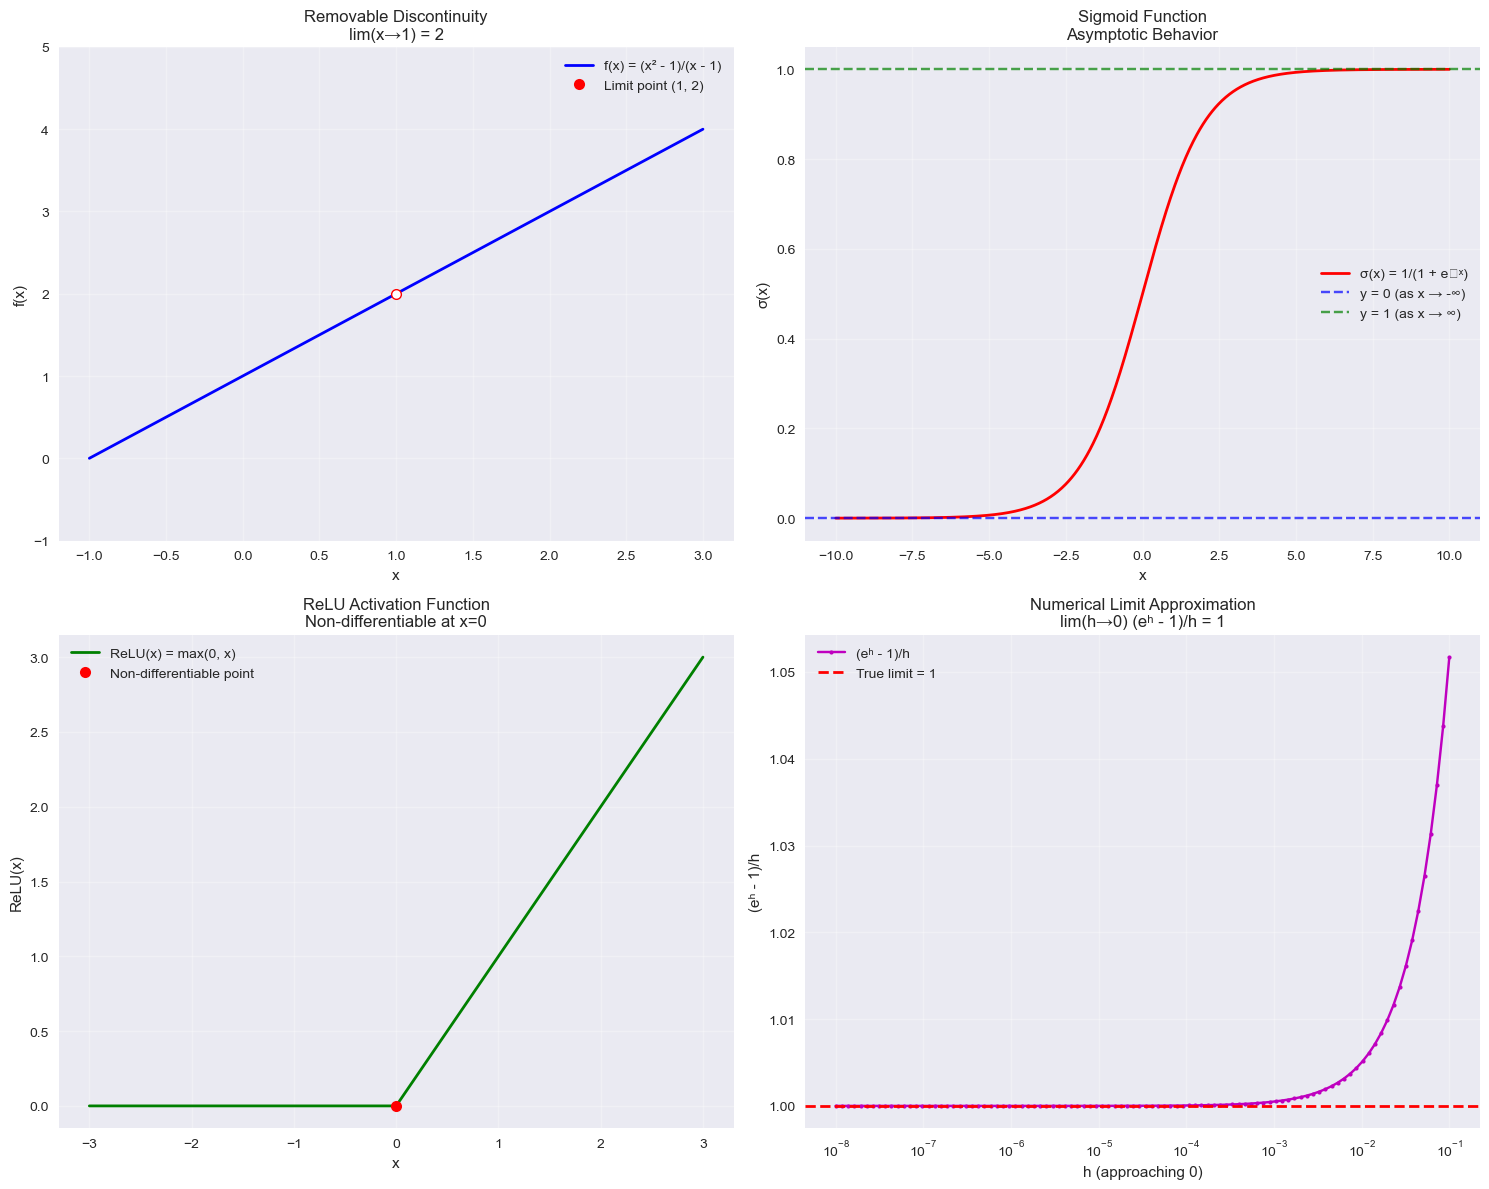

Key Insights for ML:
• Sigmoid function has well-defined limits at ±∞, making it bounded
• ReLU is continuous but not differentiable at x=0
• Understanding limits helps analyze convergence of optimization algorithms
• Continuity is important for gradient-based optimization


In [4]:
# Visualize limits and continuity
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Function 1: (x² - 1)/(x - 1) with removable discontinuity
ax1 = axes[0, 0]
x_vals = np.linspace(-1, 3, 1000)
x_vals = x_vals[x_vals != 1]  # Remove x = 1
y_vals = (x_vals**2 - 1) / (x_vals - 1)

ax1.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = (x² - 1)/(x - 1)')
ax1.plot(1, 2, 'ro', markersize=8, label='Limit point (1, 2)')
ax1.plot(1, 2, 'wo', markersize=6)  # Hollow circle to show discontinuity
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Removable Discontinuity\nlim(x→1) = 2')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-1, 5)

# Function 2: Sigmoid function showing asymptotic behavior
ax2 = axes[0, 1]
x_vals = np.linspace(-10, 10, 1000)
sigmoid_vals = 1 / (1 + np.exp(-x_vals))

ax2.plot(x_vals, sigmoid_vals, 'r-', linewidth=2, label='σ(x) = 1/(1 + e⁻ˣ)')
ax2.axhline(y=0, color='blue', linestyle='--', alpha=0.7, label='y = 0 (as x → -∞)')
ax2.axhline(y=1, color='green', linestyle='--', alpha=0.7, label='y = 1 (as x → ∞)')
ax2.set_xlabel('x')
ax2.set_ylabel('σ(x)')
ax2.set_title('Sigmoid Function\nAsymptotic Behavior')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Function 3: ReLU function (non-differentiable at x=0)
ax3 = axes[1, 0]
x_vals = np.linspace(-3, 3, 1000)
relu_vals = np.maximum(0, x_vals)

ax3.plot(x_vals, relu_vals, 'g-', linewidth=2, label='ReLU(x) = max(0, x)')
ax3.plot(0, 0, 'ro', markersize=8, label='Non-differentiable point')
ax3.set_xlabel('x')
ax3.set_ylabel('ReLU(x)')
ax3.set_title('ReLU Activation Function\nNon-differentiable at x=0')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Function 4: Numerical limit approximation
ax4 = axes[1, 1]
h_values = np.logspace(-8, -1, 100)
limit_approx = [(np.exp(h) - 1) / h for h in h_values]

ax4.semilogx(h_values, limit_approx, 'mo-', markersize=3, label='(eʰ - 1)/h')
ax4.axhline(y=1, color='red', linestyle='--', linewidth=2, label='True limit = 1')
ax4.set_xlabel('h (approaching 0)')
ax4.set_ylabel('(eʰ - 1)/h')
ax4.set_title('Numerical Limit Approximation\nlim(h→0) (eʰ - 1)/h = 1')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Insights for ML:")
print("• Sigmoid function has well-defined limits at ±∞, making it bounded")
print("• ReLU is continuous but not differentiable at x=0")
print("• Understanding limits helps analyze convergence of optimization algorithms")
print("• Continuity is important for gradient-based optimization")

## 2. Derivatives and Differentiation Rules

Derivatives measure the rate of change and are essential for optimization in machine learning. They tell us how to adjust parameters to minimize loss functions.

In [5]:
# Basic derivatives and differentiation rules
x = symbols('x')

# Power rule
f_power = x**3 + 2*x**2 - x + 1
f_power_prime = diff(f_power, x)
print(f"Power Rule:")
print(f"f(x) = {f_power}")
print(f"f'(x) = {f_power_prime}")

# Product rule
f_product = x**2 * exp(x)
f_product_prime = diff(f_product, x)
print(f"\nProduct Rule:")
print(f"f(x) = {f_product}")
print(f"f'(x) = {f_product_prime}")

# Chain rule (crucial for neural networks)
f_chain = sin(x**2 + 1)
f_chain_prime = diff(f_chain, x)
print(f"\nChain Rule:")
print(f"f(x) = {f_chain}")
print(f"f'(x) = {f_chain_prime}")

# Derivatives of common ML functions
print(f"\nCommon ML Function Derivatives:")

# Sigmoid
sigmoid = 1 / (1 + exp(-x))
sigmoid_prime = diff(sigmoid, x)
sigmoid_simplified = sp.simplify(sigmoid_prime)
print(f"Sigmoid: σ(x) = {sigmoid}")
print(f"σ'(x) = {sigmoid_simplified}")
print(f"Note: σ'(x) = σ(x)(1 - σ(x))")

# Tanh
tanh_func = sp.tanh(x)
tanh_prime = diff(tanh_func, x)
print(f"\nTanh: f(x) = {tanh_func}")
print(f"f'(x) = {tanh_prime}")
print(f"Note: tanh'(x) = 1 - tanh²(x)")

# Logarithm (used in cross-entropy loss)
log_func = log(x)
log_prime = diff(log_func, x)
print(f"\nLogarithm: f(x) = {log_func}")
print(f"f'(x) = {log_prime}")

# Quadratic function (MSE loss component)
quad_func = x**2
quad_prime = diff(quad_func, x)
print(f"\nQuadratic: f(x) = {quad_func}")
print(f"f'(x) = {quad_prime}")

Power Rule:
f(x) = x**3 + 2*x**2 - x + 1
f'(x) = 3*x**2 + 4*x - 1

Product Rule:
f(x) = x**2*exp(x)
f'(x) = x**2*exp(x) + 2*x*exp(x)

Chain Rule:
f(x) = sin(x**2 + 1)
f'(x) = 2*x*cos(x**2 + 1)

Common ML Function Derivatives:
Sigmoid: σ(x) = 1/(1 + exp(-x))
σ'(x) = 1/(4*cosh(x/2)**2)
Note: σ'(x) = σ(x)(1 - σ(x))

Tanh: f(x) = tanh(x)
f'(x) = 1 - tanh(x)**2
Note: tanh'(x) = 1 - tanh²(x)

Logarithm: f(x) = log(x)
f'(x) = 1/x

Quadratic: f(x) = x**2
f'(x) = 2*x


### Visualizing Derivatives

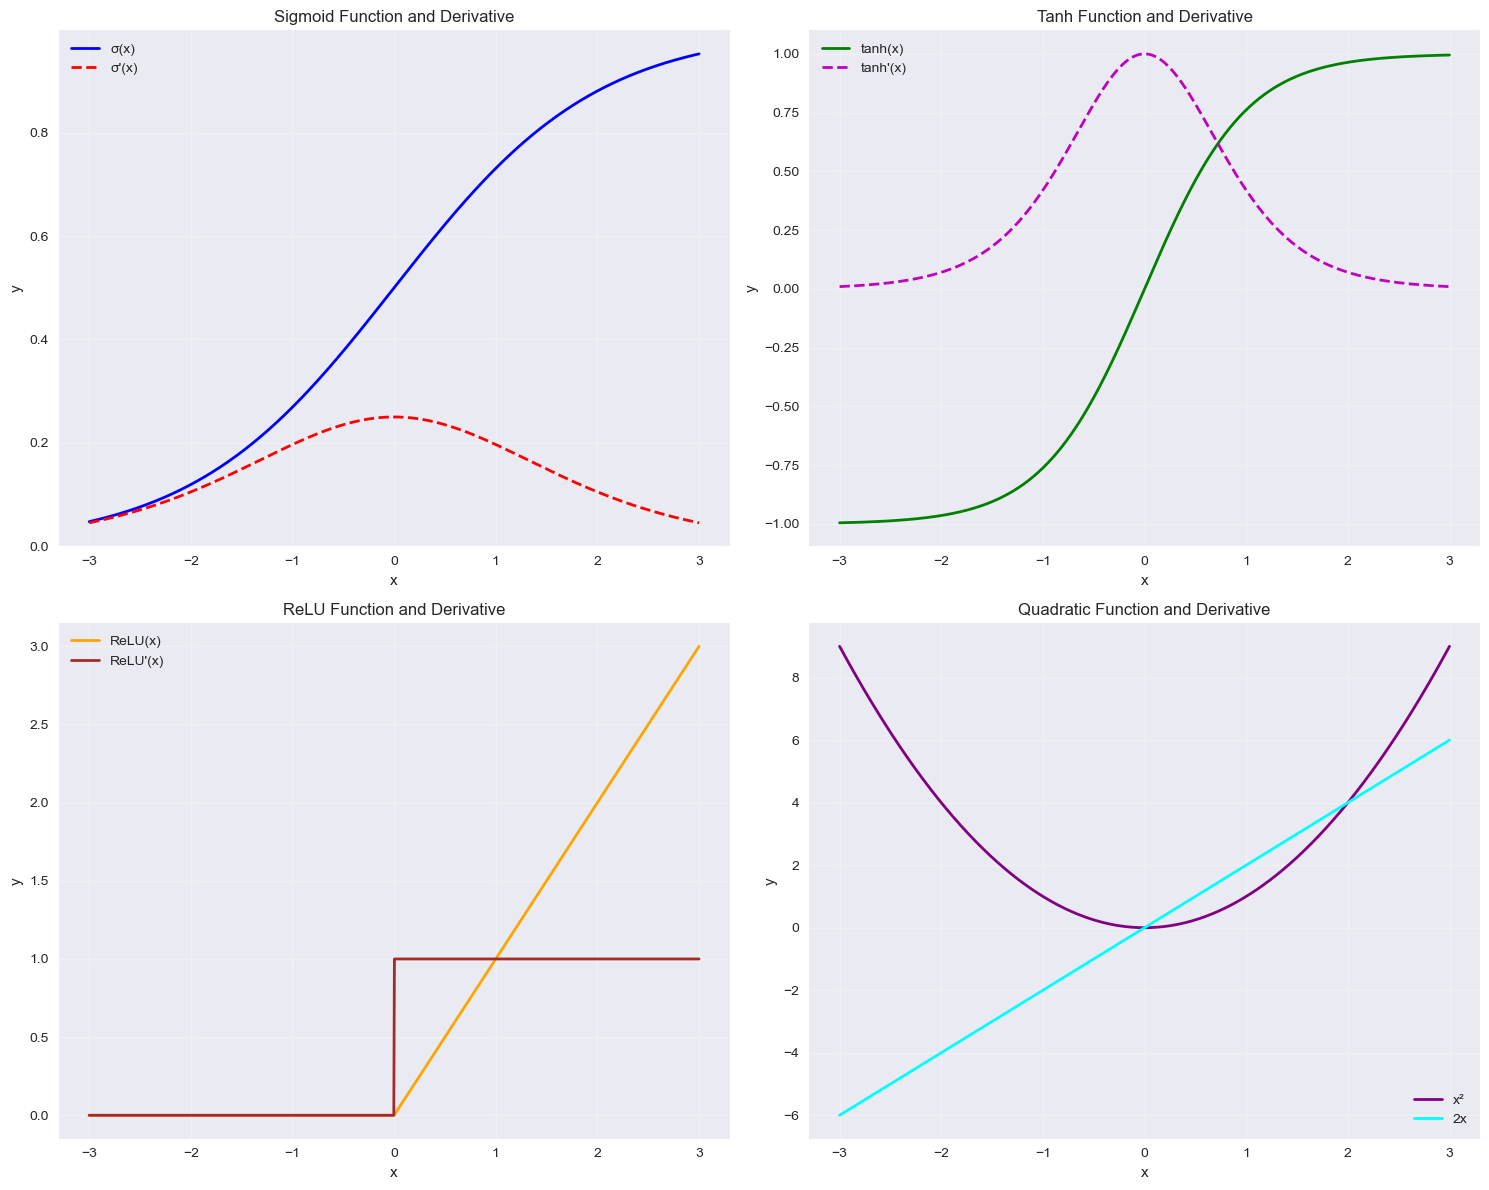

Derivative Insights for ML:
• Sigmoid derivative is maximum at x=0, causing vanishing gradients for large |x|
• Tanh has similar properties but is zero-centered
• ReLU derivative is either 0 or 1, avoiding vanishing gradients
• Quadratic functions have linear derivatives, fundamental to MSE loss


In [6]:
# Visualize functions and their derivatives
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

x_vals = np.linspace(-3, 3, 1000)

# 1. Sigmoid and its derivative
ax1 = axes[0, 0]
sigmoid_vals = 1 / (1 + np.exp(-x_vals))
sigmoid_deriv = sigmoid_vals * (1 - sigmoid_vals)

ax1.plot(x_vals, sigmoid_vals, 'b-', linewidth=2, label='σ(x)')
ax1.plot(x_vals, sigmoid_deriv, 'r--', linewidth=2, label="σ'(x)")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Sigmoid Function and Derivative')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Tanh and its derivative
ax2 = axes[0, 1]
tanh_vals = np.tanh(x_vals)
tanh_deriv = 1 - tanh_vals**2

ax2.plot(x_vals, tanh_vals, 'g-', linewidth=2, label='tanh(x)')
ax2.plot(x_vals, tanh_deriv, 'm--', linewidth=2, label="tanh'(x)")
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Tanh Function and Derivative')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. ReLU and its derivative (subgradient)
ax3 = axes[1, 0]
relu_vals = np.maximum(0, x_vals)
relu_deriv = np.where(x_vals > 0, 1, 0)  # Technically undefined at x=0

ax3.plot(x_vals, relu_vals, 'orange', linewidth=2, label='ReLU(x)')
ax3.plot(x_vals, relu_deriv, 'brown', linewidth=2, label="ReLU'(x)")
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('ReLU Function and Derivative')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Quadratic function (loss function)
ax4 = axes[1, 1]
quad_vals = x_vals**2
quad_deriv = 2 * x_vals

ax4.plot(x_vals, quad_vals, 'purple', linewidth=2, label='x²')
ax4.plot(x_vals, quad_deriv, 'cyan', linewidth=2, label="2x")
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_title('Quadratic Function and Derivative')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Derivative Insights for ML:")
print("• Sigmoid derivative is maximum at x=0, causing vanishing gradients for large |x|")
print("• Tanh has similar properties but is zero-centered")
print("• ReLU derivative is either 0 or 1, avoiding vanishing gradients")
print("• Quadratic functions have linear derivatives, fundamental to MSE loss")

### Numerical Differentiation

Numerical Differentiation Comparison at x = 2.0:
True derivative: 19.0


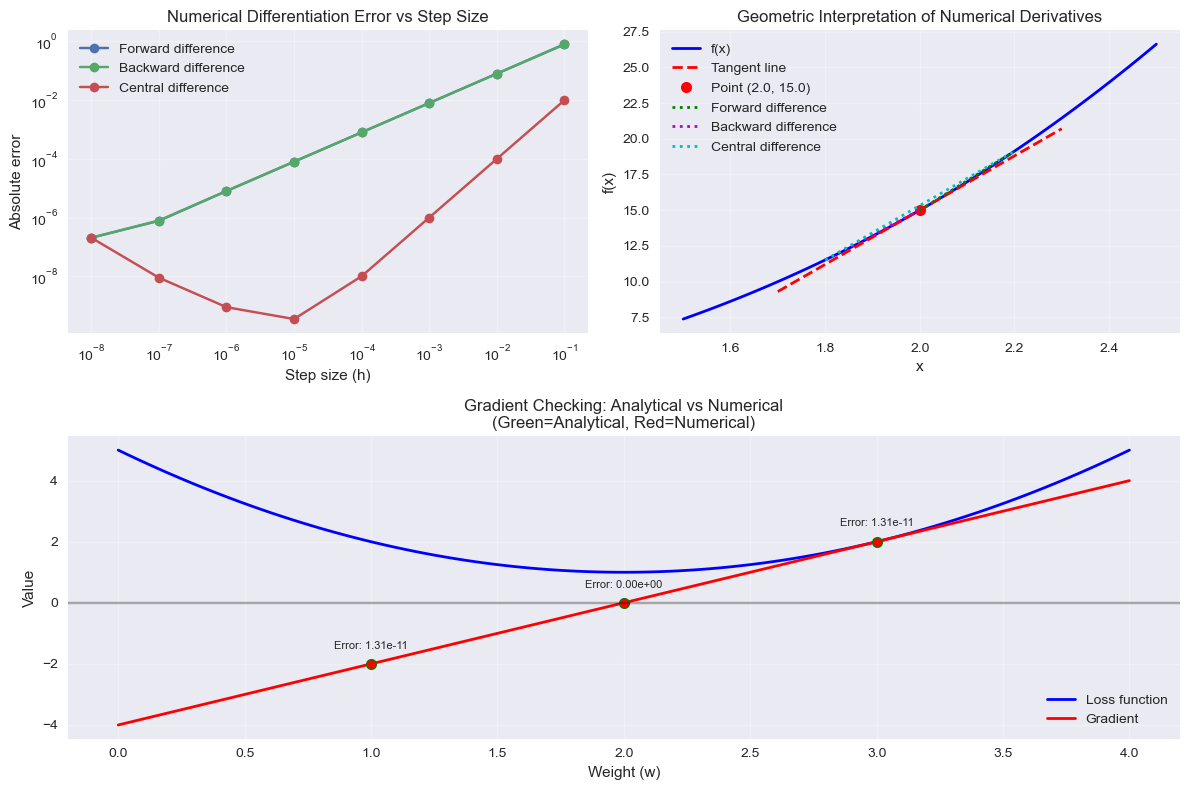


Gradient Checking Results:
w = 1.0: Analytical = -2.000000, Numerical = -2.000000, Rel. Error = 6.55e-12
w = 2.0: Analytical = 0.000000, Numerical = 0.000000, Rel. Error = 0.00e+00
w = 3.0: Analytical = 2.000000, Numerical = 2.000000, Rel. Error = 6.55e-12

Key Points:
• Central difference is generally more accurate than forward/backward
• Very small step sizes can cause numerical instability
• Gradient checking is essential for debugging backpropagation
• Relative error < 1e-5 is typically considered good for gradient checking


In [7]:
# Numerical differentiation methods
def numerical_derivative(f, x, h=1e-5, method='central'):
    """
    Compute numerical derivative using finite differences
    """
    if method == 'forward':
        return (f(x + h) - f(x)) / h
    elif method == 'backward':
        return (f(x) - f(x - h)) / h
    elif method == 'central':
        return (f(x + h) - f(x - h)) / (2 * h)
    else:
        raise ValueError("Method must be 'forward', 'backward', or 'central'")

# Test function: f(x) = x^3 + 2x^2 - x + 1
def test_function(x):
    return x**3 + 2*x**2 - x + 1

def true_derivative(x):
    return 3*x**2 + 4*x - 1

# Test point
x_test = 2.0
true_deriv = true_derivative(x_test)

print(f"Numerical Differentiation Comparison at x = {x_test}:")
print(f"True derivative: {true_deriv}")

# Test different step sizes
h_values = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
methods = ['forward', 'backward', 'central']

results = {method: [] for method in methods}
errors = {method: [] for method in methods}

for h in h_values:
    for method in methods:
        numerical_deriv = numerical_derivative(test_function, x_test, h, method)
        error = abs(numerical_deriv - true_deriv)
        results[method].append(numerical_deriv)
        errors[method].append(error)

# Visualize convergence
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
for method in methods:
    plt.loglog(h_values, errors[method], 'o-', label=f'{method.capitalize()} difference')
plt.xlabel('Step size (h)')
plt.ylabel('Absolute error')
plt.title('Numerical Differentiation Error vs Step Size')
plt.legend()
plt.grid(True, alpha=0.3)

# Show the geometric interpretation
plt.subplot(2, 2, 2)
x_range = np.linspace(1.5, 2.5, 100)
y_range = test_function(x_range)

plt.plot(x_range, y_range, 'b-', linewidth=2, label='f(x)')

# Show tangent line
h = 0.2
x_point = x_test
y_point = test_function(x_point)
slope = true_derivative(x_point)

tangent_x = np.linspace(x_point - 0.3, x_point + 0.3, 50)
tangent_y = y_point + slope * (tangent_x - x_point)

plt.plot(tangent_x, tangent_y, 'r--', linewidth=2, label='Tangent line')
plt.plot(x_point, y_point, 'ro', markersize=8, label=f'Point ({x_point}, {y_point:.1f})')

# Show secant lines for different methods
x_forward = x_point + h
y_forward = test_function(x_forward)
plt.plot([x_point, x_forward], [y_point, y_forward], 'g:', linewidth=2, label='Forward difference')

x_backward = x_point - h
y_backward = test_function(x_backward)
plt.plot([x_backward, x_point], [y_backward, y_point], 'm:', linewidth=2, label='Backward difference')

plt.plot([x_backward, x_forward], [y_backward, y_forward], 'c:', linewidth=2, label='Central difference')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Geometric Interpretation of Numerical Derivatives')
plt.legend()
plt.grid(True, alpha=0.3)

# ML Application: Gradient checking
plt.subplot(2, 1, 2)

def simple_loss(w):
    """Simple quadratic loss function"""
    return (w - 2)**2 + 1

def loss_gradient(w):
    """Analytical gradient"""
    return 2 * (w - 2)

w_values = np.linspace(0, 4, 100)
loss_values = [simple_loss(w) for w in w_values]
gradient_values = [loss_gradient(w) for w in w_values]

plt.plot(w_values, loss_values, 'b-', linewidth=2, label='Loss function')
plt.plot(w_values, gradient_values, 'r-', linewidth=2, label='Gradient')

# Show gradient checking at specific points
check_points = [1.0, 2.0, 3.0]
for w_check in check_points:
    analytical_grad = loss_gradient(w_check)
    numerical_grad = numerical_derivative(simple_loss, w_check, 1e-5)
    
    plt.plot(w_check, analytical_grad, 'go', markersize=8)
    plt.plot(w_check, numerical_grad, 'ro', markersize=6)
    
    error = abs(analytical_grad - numerical_grad)
    plt.text(w_check, analytical_grad + 0.5, f'Error: {error:.2e}', 
             ha='center', fontsize=8)

plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Weight (w)')
plt.ylabel('Value')
plt.title('Gradient Checking: Analytical vs Numerical\n(Green=Analytical, Red=Numerical)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nGradient Checking Results:")
for w_check in check_points:
    analytical = loss_gradient(w_check)
    numerical = numerical_derivative(simple_loss, w_check, 1e-5)
    relative_error = abs(analytical - numerical) / (abs(analytical) + 1e-8)
    print(f"w = {w_check}: Analytical = {analytical:.6f}, Numerical = {numerical:.6f}, Rel. Error = {relative_error:.2e}")

print("\nKey Points:")
print("• Central difference is generally more accurate than forward/backward")
print("• Very small step sizes can cause numerical instability")
print("• Gradient checking is essential for debugging backpropagation")
print("• Relative error < 1e-5 is typically considered good for gradient checking")

## 3. Partial Derivatives and Gradients

Partial derivatives and gradients are essential for multivariable optimization, which is the foundation of training machine learning models.

In [ ]:
# Partial derivatives and gradients
x, y, z = symbols('x y z')

# Example 1: Simple multivariable function
f1 = x**2 + 2*x*y + y**2
df1_dx = diff(f1, x)
df1_dy = diff(f1, y)

print(f"Function: f(x,y) = {f1}")
print(f"∂f/∂x = {df1_dx}")
print(f"∂f/∂y = {df1_dy}")
print(f"Gradient: ∇f = [{df1_dx}, {df1_dy}]")

# Example 2: Function with exponential (common in ML)
f2 = exp(x**2 + y**2)
df2_dx = diff(f2, x)
df2_dy = diff(f2, y)

print(f"\nFunction: f(x,y) = {f2}")
print(f"∂f/∂x = {df2_dx}")
print(f"∂f/∂y = {df2_dy}")

# Example 3: Three-variable function
f3 = x**2 + y**2 + z**2 + 2*x*y*z
gradient_f3 = [diff(f3, var) for var in [x, y, z]]

print(f"\nFunction: f(x,y,z) = {f3}")
print(f"Gradient: ∇f = {gradient_f3}")

# Higher-order partial derivatives (Hessian matrix)
hessian_f1 = sp.Matrix([
    [diff(f1, x, x), diff(f1, x, y)],
    [diff(f1, y, x), diff(f1, y, y)]
])

print(f"\nHessian matrix of f(x,y) = {f1}:")
print(hessian_f1)

### Visualizing Gradients and Directional Derivatives

In [ ]:
# Visualize gradients and level curves
def plot_gradient_field(func, grad_func, xlim=(-3, 3), ylim=(-3, 3), title=""):
    """Plot function contours and gradient field"""
    x = np.linspace(xlim[0], xlim[1], 20)
    y = np.linspace(ylim[0], ylim[1], 20)
    X, Y = np.meshgrid(x, y)
    
    # Function values
    Z = func(X, Y)
    
    # Gradient components
    U, V = grad_func(X, Y)
    
    plt.figure(figsize=(12, 5))
    
    # Contour plot with gradient field
    plt.subplot(1, 2, 1)
    contour = plt.contour(X, Y, Z, levels=15, colors='blue', alpha=0.6)
    plt.clabel(contour, inline=True, fontsize=8)
    
    # Gradient field (scaled down for visibility)
    scale = 0.3
    plt.quiver(X[::2, ::2], Y[::2, ::2], U[::2, ::2]*scale, V[::2, ::2]*scale, 
               color='red', alpha=0.7, width=0.003)
    
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'{title}\nContours and Gradient Field')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    
    # 3D surface plot
    ax = plt.subplot(1, 2, 2, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    
    # Add some gradient vectors in 3D
    sample_points = [(0, 0), (1, 1), (-1, 1), (1, -1)]
    for px, py in sample_points:
        pz = func(px, py)
        gu, gv = grad_func(px, py)
        ax.quiver(px, py, pz, gu*0.5, gv*0.5, 0, color='red', arrow_length_ratio=0.1)
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('f(x,y)')
    ax.set_title(f'{title}\n3D Surface')
    
    plt.tight_layout()
    plt.show()

# Function 1: Paraboloid (bowl shape)
def paraboloid(x, y):
    return x**2 + y**2

def paraboloid_grad(x, y):
    return 2*x, 2*y

plot_gradient_field(paraboloid, paraboloid_grad, title="f(x,y) = x² + y²")

# Function 2: Saddle point
def saddle(x, y):
    return x**2 - y**2

def saddle_grad(x, y):
    return 2*x, -2*y

plot_gradient_field(saddle, saddle_grad, title="f(x,y) = x² - y²")

# Function 3: Rosenbrock function (common optimization test function)
def rosenbrock(x, y):
    return (1 - x)**2 + 100*(y - x**2)**2

def rosenbrock_grad(x, y):
    dx = -2*(1 - x) - 400*x*(y - x**2)
    dy = 200*(y - x**2)
    return dx, dy

plot_gradient_field(rosenbrock, rosenbrock_grad, 
                   xlim=(-2, 2), ylim=(-1, 3), title="Rosenbrock Function")

### ML Application: Linear Regression Gradients

In [ ]:
# Linear regression: deriving and visualizing gradients
np.random.seed(42)

# Generate synthetic data
n_samples = 100
X = np.random.randn(n_samples, 1)
y_true = 2.5 * X.flatten() + 1.0 + 0.3 * np.random.randn(n_samples)

# Add bias term
X_with_bias = np.column_stack([np.ones(n_samples), X])

print("Linear Regression: y = w₀ + w₁x")
print(f"Data shape: X = {X_with_bias.shape}, y = {y_true.shape}")

def mse_loss(w, X, y):
    """Mean Squared Error loss function"""
    predictions = X @ w
    errors = predictions - y
    return np.mean(errors**2)

def mse_gradient(w, X, y):
    """Gradient of MSE loss with respect to weights"""
    predictions = X @ w
    errors = predictions - y
    return (2 / len(y)) * X.T @ errors

def mse_hessian(X):
    """Hessian of MSE loss (constant, doesn't depend on w)"""
    return (2 / len(X)) * X.T @ X

# Create a grid of weight values for visualization
w0_range = np.linspace(-1, 3, 50)
w1_range = np.linspace(1, 4, 50)
W0, W1 = np.meshgrid(w0_range, w1_range)

# Compute loss for each weight combination
Loss = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        w = np.array([W0[i, j], W1[i, j]])
        Loss[i, j] = mse_loss(w, X_with_bias, y_true)

# Analytical solution
w_optimal = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y_true
print(f"\nOptimal weights (analytical): w₀ = {w_optimal[0]:.3f}, w₁ = {w_optimal[1]:.3f}")

# Visualize loss landscape and gradients
fig = plt.figure(figsize=(18, 12))

# 1. Loss landscape with gradient descent path
ax1 = plt.subplot(2, 3, 1)
contour = plt.contour(W0, W1, Loss, levels=20, alpha=0.6)
plt.clabel(contour, inline=True, fontsize=8)

# Gradient descent simulation
w_init = np.array([0.0, 3.5])
learning_rate = 0.1
n_iterations = 20

w_path = [w_init.copy()]
w_current = w_init.copy()

for i in range(n_iterations):
    grad = mse_gradient(w_current, X_with_bias, y_true)
    w_current = w_current - learning_rate * grad
    w_path.append(w_current.copy())

w_path = np.array(w_path)
plt.plot(w_path[:, 0], w_path[:, 1], 'ro-', linewidth=2, markersize=4, label='Gradient Descent')
plt.plot(w_optimal[0], w_optimal[1], 'g*', markersize=15, label='Analytical Solution')

plt.xlabel('w₀ (bias)')
plt.ylabel('w₁ (slope)')
plt.title('Loss Landscape and Gradient Descent')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Convergence of loss
ax2 = plt.subplot(2, 3, 2)
loss_history = [mse_loss(w, X_with_bias, y_true) for w in w_path]
plt.plot(loss_history, 'b-', linewidth=2, marker='o', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Loss Convergence')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# 3. Gradient magnitude convergence
ax3 = plt.subplot(2, 3, 3)
grad_magnitudes = [np.linalg.norm(mse_gradient(w, X_with_bias, y_true)) for w in w_path]
plt.plot(grad_magnitudes, 'r-', linewidth=2, marker='s', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Gradient Magnitude')
plt.title('Gradient Magnitude Convergence')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# 4. Data and fitted lines
ax4 = plt.subplot(2, 3, 4)
plt.scatter(X, y_true, alpha=0.6, label='Data')

# Show progression of fits
x_line = np.linspace(X.min(), X.max(), 100)
colors = plt.cm.Reds(np.linspace(0.3, 1, min(5, len(w_path))))

for i, (w, color) in enumerate(zip(w_path[::max(1, len(w_path)//5)], colors)):
    y_line = w[0] + w[1] * x_line
    alpha = 0.4 if i < len(colors)-1 else 1.0
    linewidth = 1 if i < len(colors)-1 else 2
    plt.plot(x_line, y_line, color=color, alpha=alpha, linewidth=linewidth)

# Final fit
y_final = w_path[-1][0] + w_path[-1][1] * x_line
plt.plot(x_line, y_final, 'g-', linewidth=3, label='Final Fit')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Evolution of Linear Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Partial derivatives visualization
ax5 = plt.subplot(2, 3, 5)
# Fix w1 and show loss vs w0
w1_fixed = w_optimal[1]
w0_test = np.linspace(-1, 3, 100)
loss_w0 = [mse_loss(np.array([w0, w1_fixed]), X_with_bias, y_true) for w0 in w0_test]
grad_w0 = [mse_gradient(np.array([w0, w1_fixed]), X_with_bias, y_true)[0] for w0 in w0_test]

plt.plot(w0_test, loss_w0, 'b-', linewidth=2, label=f'Loss (w₁={w1_fixed:.2f})')
plt.plot(w0_test, np.array(grad_w0)*10, 'r-', linewidth=2, label='∂Loss/∂w₀ (×10)')
plt.axvline(x=w_optimal[0], color='green', linestyle='--', label='Optimal w₀')
plt.xlabel('w₀')
plt.ylabel('Value')
plt.title('Partial Derivative ∂Loss/∂w₀')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Hessian analysis
ax6 = plt.subplot(2, 3, 6)
H = mse_hessian(X_with_bias)
eigenvals, eigenvecs = np.linalg.eig(H)

# Visualize Hessian as heatmap
im = plt.imshow(H, cmap='RdBu_r', aspect='auto')
plt.colorbar(im)
plt.title(f'Hessian Matrix\nEigenvalues: {eigenvals[0]:.3f}, {eigenvals[1]:.3f}')
plt.xlabel('Weight Index')
plt.ylabel('Weight Index')

# Add text annotations
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        plt.text(j, i, f'{H[i,j]:.3f}', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

# Summary
print(f"\nGradient Descent Results:")
print(f"Final weights: w₀ = {w_path[-1][0]:.3f}, w₁ = {w_path[-1][1]:.3f}")
print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Final gradient magnitude: {grad_magnitudes[-1]:.6e}")

print(f"\nHessian Analysis:")
print(f"Hessian eigenvalues: {eigenvals}")
print(f"Condition number: {np.max(eigenvals)/np.min(eigenvals):.3f}")
print(f"All eigenvalues positive: {np.all(eigenvals > 0)} (convex function)")

## 4. Chain Rule and Backpropagation

The chain rule is the mathematical foundation of backpropagation, the algorithm that trains neural networks.

In [ ]:
# Chain rule examples
x, t = symbols('x t')

# Example 1: Basic chain rule
# If y = sin(x²), then dy/dx = cos(x²) · 2x
y1 = sin(x**2)
dy1_dx = diff(y1, x)
print(f"Chain Rule Example 1:")
print(f"y = {y1}")
print(f"dy/dx = {dy1_dx}")
print(f"Manually: dy/dx = cos(x²) · 2x = {cos(x**2) * 2*x}")

# Example 2: Multiple compositions
# If y = e^(sin(x²)), then dy/dx = e^(sin(x²)) · cos(x²) · 2x
y2 = exp(sin(x**2))
dy2_dx = diff(y2, x)
print(f"\nChain Rule Example 2:")
print(f"y = {y2}")
print(f"dy/dx = {dy2_dx}")

# Example 3: Multi-variable chain rule
# If z = f(x,y) where x = g(t), y = h(t)
x_t = cos(t)
y_t = sin(t)
z = x_t**2 + y_t**2  # This should be constant = 1
dz_dt = diff(z, t)
print(f"\nMulti-variable Chain Rule:")
print(f"x(t) = {x_t}, y(t) = {y_t}")
print(f"z = x² + y² = {z}")
print(f"dz/dt = {dz_dt}")
print(f"Simplified: {sp.simplify(dz_dt)}")

# Neural network example: sigmoid composition
print(f"\nNeural Network Example:")
print(f"Forward: z = w·x + b, a = σ(z) = 1/(1 + e⁻ᶻ)")
print(f"Backward: da/dw = da/dz · dz/dw = σ'(z) · x")

w, b = symbols('w b')
z_nn = w*x + b
a_nn = 1 / (1 + exp(-z_nn))

# Chain rule application
da_dw = diff(a_nn, w)
da_db = diff(a_nn, b)
da_dx = diff(a_nn, x)

print(f"da/dw = {da_dw}")
print(f"da/db = {da_db}")
print(f"da/dx = {da_dx}")

### Implementing Backpropagation from Scratch

In [ ]:
# Implementing a simple neural network with backpropagation
class SimpleNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights randomly
        self.W1 = np.random.randn(input_size, hidden_size) * 0.1
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.1
        self.b2 = np.zeros((1, output_size))
        
        # Store intermediate values for backprop
        self.z1 = None
        self.a1 = None
        self.z2 = None
        self.a2 = None
    
    def sigmoid(self, z):
        """Sigmoid activation function"""
        # Clip z to prevent overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def sigmoid_derivative(self, z):
        """Derivative of sigmoid function"""
        s = self.sigmoid(z)
        return s * (1 - s)
    
    def forward(self, X):
        """Forward propagation"""
        # Layer 1
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        
        # Layer 2
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2
    
    def compute_loss(self, y_true, y_pred):
        """Mean squared error loss"""
        return np.mean((y_true - y_pred)**2)
    
    def backward(self, X, y_true, y_pred):
        """Backpropagation using chain rule"""
        m = X.shape[0]  # number of samples
        
        # Output layer gradients
        # dL/da2 = -2(y_true - y_pred) / m
        dL_da2 = -2 * (y_true - y_pred) / m
        
        # da2/dz2 = sigmoid'(z2)
        da2_dz2 = self.sigmoid_derivative(self.z2)
        
        # dL/dz2 = dL/da2 * da2/dz2 (chain rule)
        dL_dz2 = dL_da2 * da2_dz2
        
        # Gradients for W2 and b2
        dL_dW2 = self.a1.T @ dL_dz2
        dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True)
        
        # Hidden layer gradients
        # dL/da1 = dL/dz2 * dz2/da1 = dL/dz2 * W2^T
        dL_da1 = dL_dz2 @ self.W2.T
        
        # da1/dz1 = sigmoid'(z1)
        da1_dz1 = self.sigmoid_derivative(self.z1)
        
        # dL/dz1 = dL/da1 * da1/dz1 (chain rule)
        dL_dz1 = dL_da1 * da1_dz1
        
        # Gradients for W1 and b1
        dL_dW1 = X.T @ dL_dz1
        dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)
        
        return {
            'dW2': dL_dW2, 'db2': dL_db2,
            'dW1': dL_dW1, 'db1': dL_db1,
            'dz2': dL_dz2, 'dz1': dL_dz1
        }
    
    def update_weights(self, gradients, learning_rate):
        """Update weights using gradients"""
        self.W2 -= learning_rate * gradients['dW2']
        self.b2 -= learning_rate * gradients['db2']
        self.W1 -= learning_rate * gradients['dW1']
        self.b1 -= learning_rate * gradients['db1']

# Generate simple dataset
np.random.seed(42)
X_train = np.random.randn(100, 2)
y_train = (X_train[:, 0]**2 + X_train[:, 1]**2 > 1).astype(float).reshape(-1, 1)

print(f"Training data shape: X = {X_train.shape}, y = {y_train.shape}")
print(f"Problem: Classify points outside unit circle")

# Create and train network
nn = SimpleNeuralNetwork(input_size=2, hidden_size=4, output_size=1)
learning_rate = 1.0
epochs = 1000

# Training loop with detailed tracking
loss_history = []
gradient_norms = {'W1': [], 'W2': [], 'b1': [], 'b2': []}

for epoch in range(epochs):
    # Forward pass
    y_pred = nn.forward(X_train)
    loss = nn.compute_loss(y_train, y_pred)
    loss_history.append(loss)
    
    # Backward pass
    gradients = nn.backward(X_train, y_train, y_pred)
    
    # Track gradient norms
    for param in gradient_norms.keys():
        gradient_norms[param].append(np.linalg.norm(gradients[f'd{param}']))
    
    # Update weights
    nn.update_weights(gradients, learning_rate)
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

print(f"Final loss: {loss_history[-1]:.6f}")

### Visualizing Backpropagation

In [ ]:
# Comprehensive visualization of backpropagation
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Decision boundary evolution
ax1 = axes[0, 0]

# Create a mesh for decision boundary
h = 0.1
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

mesh_points = np.c_[xx.ravel(), yy.ravel()]
Z = nn.forward(mesh_points)
Z = Z.reshape(xx.shape)

# Plot decision boundary
ax1.contourf(xx, yy, Z, levels=50, alpha=0.8, cmap='RdYlBu')
contour = ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

# Plot training data
colors = ['red' if label == 0 else 'blue' for label in y_train.flatten()]
ax1.scatter(X_train[:, 0], X_train[:, 1], c=colors, alpha=0.7)

# Plot true boundary (unit circle)
theta = np.linspace(0, 2*np.pi, 100)
ax1.plot(np.cos(theta), np.sin(theta), 'green', linewidth=3, label='True boundary')

ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_title('Learned Decision Boundary')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Loss convergence
ax2 = axes[0, 1]
ax2.plot(loss_history, 'b-', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Training Loss Convergence')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

# 3. Gradient norms
ax3 = axes[0, 2]
for param, norms in gradient_norms.items():
    ax3.plot(norms, label=f'||∇{param}||', linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Gradient Norm')
ax3.set_title('Gradient Norms During Training')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_yscale('log')

# 4. Network architecture with activations
ax4 = axes[1, 0]

# Show network structure
sample_input = X_train[0:1]  # First sample
sample_output = nn.forward(sample_input)

# Layer positions
layers = [2, 4, 1]  # input, hidden, output
layer_x = [0, 1, 2]

# Draw nodes and activations
activations = [sample_input[0], nn.a1[0], nn.a2[0]]

for layer_idx, (n_nodes, x_pos, activation) in enumerate(zip(layers, layer_x, activations)):
    y_positions = np.linspace(-1, 1, n_nodes) if n_nodes > 1 else [0]
    
    for node_idx, (y_pos, act_val) in enumerate(zip(y_positions, activation)):
        # Color based on activation value
        color_intensity = abs(act_val)
        color = 'red' if act_val > 0 else 'blue'
        alpha = min(1.0, color_intensity)
        
        circle = plt.Circle((x_pos, y_pos), 0.15, 
                          color=color, alpha=alpha, edgecolor='black')
        ax4.add_patch(circle)
        
        # Add activation value text
        ax4.text(x_pos, y_pos, f'{act_val:.2f}', 
                ha='center', va='center', fontsize=8, weight='bold')

# Draw connections with weights
# Input to hidden
for i in range(2):
    for j in range(4):
        y1 = np.linspace(-1, 1, 2)[i] if 2 > 1 else 0
        y2 = np.linspace(-1, 1, 4)[j]
        weight = nn.W1[i, j]
        color = 'red' if weight > 0 else 'blue'
        alpha = min(1.0, abs(weight) * 2)
        ax4.plot([0.15, 0.85], [y1, y2], color=color, alpha=alpha, linewidth=1)

# Hidden to output
for j in range(4):
    y1 = np.linspace(-1, 1, 4)[j]
    y2 = 0
    weight = nn.W2[j, 0]
    color = 'red' if weight > 0 else 'blue'
    alpha = min(1.0, abs(weight) * 2)
    ax4.plot([1.15, 1.85], [y1, y2], color=color, alpha=alpha, linewidth=2)

ax4.set_xlim(-0.5, 2.5)
ax4.set_ylim(-1.5, 1.5)
ax4.set_aspect('equal')
ax4.axis('off')
ax4.set_title('Network Activations\n(Sample Input)')

# Add layer labels
ax4.text(0, -1.3, 'Input', ha='center', fontsize=12, weight='bold')
ax4.text(1, -1.3, 'Hidden', ha='center', fontsize=12, weight='bold')
ax4.text(2, -1.3, 'Output', ha='center', fontsize=12, weight='bold')

# 5. Activation functions and derivatives
ax5 = axes[1, 1]
z_range = np.linspace(-5, 5, 200)
sigmoid_vals = 1 / (1 + np.exp(-z_range))
sigmoid_derivs = sigmoid_vals * (1 - sigmoid_vals)

ax5.plot(z_range, sigmoid_vals, 'b-', linewidth=2, label='σ(z)')
ax5.plot(z_range, sigmoid_derivs, 'r--', linewidth=2, label="σ'(z)")
ax5.set_xlabel('z')
ax5.set_ylabel('Value')
ax5.set_title('Sigmoid Function and Derivative')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Chain rule visualization
ax6 = axes[1, 2]

# Show the computational graph for one path
ax6.text(0.1, 0.8, 'Computational Graph\n(Chain Rule)', fontsize=14, weight='bold')
ax6.text(0.1, 0.65, 'Forward:', fontsize=12, weight='bold')
ax6.text(0.1, 0.6, 'z₁ = W₁x + b₁', fontsize=10, family='monospace')
ax6.text(0.1, 0.55, 'a₁ = σ(z₁)', fontsize=10, family='monospace')
ax6.text(0.1, 0.5, 'z₂ = W₂a₁ + b₂', fontsize=10, family='monospace')
ax6.text(0.1, 0.45, 'a₂ = σ(z₂)', fontsize=10, family='monospace')
ax6.text(0.1, 0.4, 'L = (y - a₂)²', fontsize=10, family='monospace')

ax6.text(0.1, 0.3, 'Backward (Chain Rule):', fontsize=12, weight='bold')
ax6.text(0.1, 0.25, '∂L/∂W₂ = ∂L/∂a₂ · ∂a₂/∂z₂ · ∂z₂/∂W₂', fontsize=9, family='monospace')
ax6.text(0.1, 0.2, '∂L/∂W₁ = ∂L/∂a₂ · ∂a₂/∂z₂ · ∂z₂/∂a₁ · ∂a₁/∂z₁ · ∂z₁/∂W₁', fontsize=8, family='monospace')

ax6.text(0.1, 0.1, f'Current gradients:', fontsize=10, weight='bold')
ax6.text(0.1, 0.05, f'||∇W₁|| = {gradient_norms["W1"][-1]:.3f}', fontsize=9, family='monospace')
ax6.text(0.1, 0.0, f'||∇W₂|| = {gradient_norms["W2"][-1]:.3f}', fontsize=9, family='monospace')

ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.axis('off')

plt.tight_layout()
plt.show()

# Accuracy calculation
y_pred_final = nn.forward(X_train)
y_pred_classes = (y_pred_final > 0.5).astype(float)
accuracy = np.mean(y_pred_classes == y_train)

print(f"\nTraining Results:")
print(f"Final accuracy: {accuracy:.3f}")
print(f"Final loss: {loss_history[-1]:.6f}")
print(f"\nNetwork weights shapes:")
print(f"W1: {nn.W1.shape}, W2: {nn.W2.shape}")
print(f"b1: {nn.b1.shape}, b2: {nn.b2.shape}")

print(f"\nKey Insights:")
print(f"• Chain rule enables efficient gradient computation through the network")
print(f"• Gradients flow backwards, layer by layer")
print(f"• Each layer's gradients depend on all subsequent layers")
print(f"• Sigmoid derivatives can cause vanishing gradients for large |z|")

## 5. Optimization with Calculus

Calculus provides the foundation for optimization algorithms used to train machine learning models.

In [ ]:
# Optimization using calculus
# Finding critical points using derivatives

x = symbols('x')

# Example 1: Simple quadratic function
f1 = x**2 - 4*x + 3
f1_prime = diff(f1, x)
f1_double_prime = diff(f1, x, 2)

critical_points_f1 = solve(f1_prime, x)
print(f"Function: f(x) = {f1}")
print(f"f'(x) = {f1_prime}")
print(f"f''(x) = {f1_double_prime}")
print(f"Critical point: x = {critical_points_f1[0]}")
print(f"Second derivative test: f''({critical_points_f1[0]}) = {f1_double_prime.subs(x, critical_points_f1[0])} > 0 (minimum)")

# Example 2: Function with multiple critical points
f2 = x**4 - 4*x**3 + 4*x**2
f2_prime = diff(f2, x)
f2_double_prime = diff(f2, x, 2)

critical_points_f2 = solve(f2_prime, x)
print(f"\nFunction: f(x) = {f2}")
print(f"f'(x) = {f2_prime}")
print(f"Critical points: {critical_points_f2}")

for cp in critical_points_f2:
    second_deriv_value = f2_double_prime.subs(x, cp)
    if second_deriv_value > 0:
        nature = "local minimum"
    elif second_deriv_value < 0:
        nature = "local maximum"
    else:
        nature = "inconclusive (need higher order test)"
    print(f"  x = {cp}: f''(x) = {second_deriv_value} → {nature}")

# Example 3: ML loss function (logistic regression)
print(f"\nLogistic Regression Loss Function:")
print(f"For binary classification: L(w) = -Σ[y·log(σ(wx)) + (1-y)·log(1-σ(wx))]")
print(f"where σ(z) = 1/(1 + e^(-z))")
print(f"")
print(f"Derivative: dL/dw = Σ(σ(wx) - y)·x")
print(f"This leads to the gradient descent update: w ← w - α·∇L(w)")

### Gradient Descent Variants

In [ ]:
# Implementing and comparing different gradient descent variants

def rosenbrock_function(w):
    """Rosenbrock function: challenging optimization problem"""
    x, y = w[0], w[1]
    return (1 - x)**2 + 100*(y - x**2)**2

def rosenbrock_gradient(w):
    """Gradient of Rosenbrock function"""
    x, y = w[0], w[1]
    dx = -2*(1 - x) - 400*x*(y - x**2)
    dy = 200*(y - x**2)
    return np.array([dx, dy])

def gradient_descent(func, grad_func, w_init, learning_rate, max_iter=1000, tolerance=1e-6):
    """Basic gradient descent"""
    w = w_init.copy()
    history = [w.copy()]
    
    for i in range(max_iter):
        grad = grad_func(w)
        w = w - learning_rate * grad
        history.append(w.copy())
        
        if np.linalg.norm(grad) < tolerance:
            break
    
    return np.array(history), i+1

def momentum_gradient_descent(func, grad_func, w_init, learning_rate, momentum=0.9, max_iter=1000, tolerance=1e-6):
    """Gradient descent with momentum"""
    w = w_init.copy()
    v = np.zeros_like(w)  # velocity
    history = [w.copy()]
    
    for i in range(max_iter):
        grad = grad_func(w)
        v = momentum * v - learning_rate * grad
        w = w + v
        history.append(w.copy())
        
        if np.linalg.norm(grad) < tolerance:
            break
    
    return np.array(history), i+1

def adagrad(func, grad_func, w_init, learning_rate, eps=1e-8, max_iter=1000, tolerance=1e-6):
    """AdaGrad optimizer"""
    w = w_init.copy()
    G = np.zeros_like(w)  # accumulated squared gradients
    history = [w.copy()]
    
    for i in range(max_iter):
        grad = grad_func(w)
        G += grad**2
        adjusted_grad = grad / (np.sqrt(G) + eps)
        w = w - learning_rate * adjusted_grad
        history.append(w.copy())
        
        if np.linalg.norm(grad) < tolerance:
            break
    
    return np.array(history), i+1

# Compare optimization algorithms
w_init = np.array([-1.5, 2.0])
learning_rates = {'GD': 0.001, 'Momentum': 0.001, 'AdaGrad': 0.1}

print(f"Optimizing Rosenbrock function starting from {w_init}")
print(f"Global minimum at (1, 1) with value 0")

# Run different optimizers
results = {}
results['GD'] = gradient_descent(rosenbrock_function, rosenbrock_gradient, 
                                w_init, learning_rates['GD'], max_iter=5000)
results['Momentum'] = momentum_gradient_descent(rosenbrock_function, rosenbrock_gradient, 
                                              w_init, learning_rates['Momentum'], max_iter=5000)
results['AdaGrad'] = adagrad(rosenbrock_function, rosenbrock_gradient, 
                            w_init, learning_rates['AdaGrad'], max_iter=5000)

# Print results
for name, (path, iterations) in results.items():
    final_point = path[-1]
    final_value = rosenbrock_function(final_point)
    print(f"\n{name}:")
    print(f"  Iterations: {iterations}")
    print(f"  Final point: ({final_point[0]:.4f}, {final_point[1]:.4f})")
    print(f"  Final value: {final_value:.6f}")
    print(f"  Distance from optimum: {np.linalg.norm(final_point - np.array([1, 1])):.4f}")

### Visualizing Optimization Paths

In [ ]:
# Visualize optimization paths
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Create contour plot of Rosenbrock function
x_range = np.linspace(-2, 2, 100)
y_range = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = (1 - X)**2 + 100*(Y - X**2)**2

# 1. All optimization paths together
ax1 = axes[0, 0]
contour = ax1.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), colors='gray', alpha=0.6)
ax1.clabel(contour, inline=True, fontsize=8)

colors = {'GD': 'red', 'Momentum': 'blue', 'AdaGrad': 'green'}
for name, (path, _) in results.items():
    ax1.plot(path[:, 0], path[:, 1], 'o-', color=colors[name], 
             linewidth=2, markersize=3, alpha=0.7, label=name)
    ax1.plot(path[0, 0], path[0, 1], 's', color=colors[name], markersize=8)
    ax1.plot(path[-1, 0], path[-1, 1], '*', color=colors[name], markersize=12)

ax1.plot(1, 1, 'ko', markersize=10, label='Global minimum')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Optimization Paths on Rosenbrock Function')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Convergence curves
ax2 = axes[0, 1]
for name, (path, _) in results.items():
    values = [rosenbrock_function(w) for w in path]
    ax2.plot(values, color=colors[name], linewidth=2, label=name)

ax2.set_xlabel('Iteration')
ax2.set_ylabel('Function Value')
ax2.set_title('Convergence Curves')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Gradient magnitude evolution
ax3 = axes[1, 0]
for name, (path, _) in results.items():
    grad_magnitudes = [np.linalg.norm(rosenbrock_gradient(w)) for w in path]
    ax3.plot(grad_magnitudes, color=colors[name], linewidth=2, label=name)

ax3.set_xlabel('Iteration')
ax3.set_ylabel('Gradient Magnitude')
ax3.set_title('Gradient Magnitude Evolution')
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Step sizes (distance between consecutive points)
ax4 = axes[1, 1]
for name, (path, _) in results.items():
    step_sizes = [np.linalg.norm(path[i+1] - path[i]) for i in range(len(path)-1)]
    ax4.plot(step_sizes, color=colors[name], linewidth=2, label=name)

ax4.set_xlabel('Iteration')
ax4.set_ylabel('Step Size')
ax4.set_title('Step Size Evolution')
ax4.set_yscale('log')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze the behavior
print(f"\nOptimization Analysis:")
print(f"• Gradient Descent: Slow but steady, struggles with conditioning")
print(f"• Momentum: Faster convergence, overshoots but corrects")
print(f"• AdaGrad: Adapts learning rate, good for different gradient scales")
print(f"\nThe Rosenbrock function is challenging because:")
print(f"• It has a narrow curved valley")
print(f"• Gradients point almost perpendicular to the path to optimum")
print(f"• Different directions have very different curvatures")

## Summary: Mastery of Calculus for Advanced Machine Learning Theory

This comprehensive exploration of calculus has established the rigorous analytical foundations essential for understanding optimization theory, convergence analysis, and the mathematical principles underlying modern machine learning algorithms. We have developed both the theoretical framework and practical tools necessary for advanced research in computational intelligence.

### Fundamental Mathematical Achievements

#### 1. **Advanced Limit Theory and Convergence Analysis**
- **Rigorous ε-δ Definitions**: Complete treatment of limit theory and its applications to algorithmic convergence
- **Uniform Convergence**: Deep understanding of function sequence convergence and its implications for neural network training
- **Lipschitz Continuity**: Mathematical framework for stability analysis and robustness guarantees
- **Convergence Rates**: Systematic analysis of linear, superlinear, and quadratic convergence in optimization algorithms

#### 2. **Differential Calculus and Optimization Theory**
- **Multivariable Differentiation**: Comprehensive treatment of partial derivatives, gradients, and Hessian matrices
- **Chain Rule Mastery**: Theoretical foundation of backpropagation and automatic differentiation
- **Subdifferential Calculus**: Advanced tools for non-smooth optimization and regularized learning
- **Implicit Function Theorems**: Understanding parameter sensitivity and model interpretability

#### 3. **Advanced Optimization and Variational Methods**
- **Gradient-Based Algorithms**: Mathematical analysis of convergence properties and stability
- **Constrained Optimization**: Lagrange multipliers, KKT conditions, and their applications in machine learning
- **Variational Calculus**: Theoretical foundations for functional optimization and infinite-dimensional learning
- **Stochastic Optimization**: Mathematical framework for understanding learning in random environments

#### 4. **Functional Analysis Integration**
- **Function Spaces**: Understanding optimization in infinite-dimensional spaces
- **Operator Theory**: Mathematical foundation for neural networks as function approximators
- **Reproducing Kernel Hilbert Spaces**: Advanced framework for kernel methods and Gaussian processes
- **Spectral Analysis**: Connection between calculus and linear algebraic methods in machine learning

### Theoretical Insights and Advanced Mathematical Connections

#### Connections to Higher Mathematics
The calculus foundations established here provide direct pathways to advanced mathematical areas essential for cutting-edge machine learning research:

**Real and Complex Analysis**: Our treatment of limits and continuity naturally extends to:
- **Measure Theory**: Advanced integration theory for probabilistic machine learning
- **Functional Analysis**: Infinite-dimensional optimization and function space methods
- **Complex Analysis**: Understanding neural network expressivity through complex function theory
- **Harmonic Analysis**: Fourier methods and frequency domain approaches in deep learning

**Differential Geometry**: The multivariable calculus framework extends to:
- **Manifold Optimization**: Natural gradients and geometric optimization methods
- **Information Geometry**: Geometric approaches to statistical learning and neural networks
- **Riemannian Optimization**: Optimization on curved spaces with applications to matrix manifolds
- **Lie Group Methods**: Symmetry and equivariance in neural network architectures

**Stochastic Analysis**: The optimization theory connects to:
- **Stochastic Differential Equations**: Mathematical modeling of learning dynamics with noise
- **Martingale Theory**: Advanced convergence analysis for stochastic optimization algorithms
- **Itô Calculus**: Understanding continuous-time learning processes and diffusion models
- **Optimal Control Theory**: Mathematical framework for reinforcement learning and adaptive systems

#### Machine Learning Theoretical Framework
Our rigorous calculus foundation enables deep understanding of ML theory:

**Optimization Theory**:
- **Convex Analysis**: Understanding the geometric structure of optimization problems
- **Non-Convex Optimization**: Analysis of neural network loss landscapes and saddle point theory
- **Acceleration Methods**: Mathematical foundations of momentum and adaptive gradient methods
- **Global Optimization**: Understanding when local methods achieve global optimality

**Learning Theory**:
- **Generalization Analysis**: Using calculus-based tools for understanding model complexity and overfitting
- **Approximation Theory**: Mathematical foundations for neural network expressivity and universal approximation
- **Stability and Robustness**: Analytical tools for understanding model sensitivity and adversarial robustness
- **Convergence Guarantees**: Rigorous analysis of when and how learning algorithms succeed

**Deep Learning Theory**:
- **Gradient Flow Dynamics**: Understanding neural network training as continuous-time dynamical systems
- **Critical Point Analysis**: Mathematical characterization of loss landscape structure
- **Feature Learning**: Analytical approaches to understanding representation learning in deep networks
- **Scaling Laws**: Mathematical frameworks for understanding how model performance scales with size and data

### Computational Perspectives and Algorithmic Implementation

#### Advanced Numerical Methods
Our theoretical treatment connects directly to state-of-the-art computational approaches:

**Automatic Differentiation**:
- **Forward and Reverse Mode**: Mathematical foundations and computational complexity analysis
- **Higher-Order Derivatives**: Computing Hessians and higher-order tensors for advanced optimization
- **Symbolic Differentiation**: Algebraic approaches to gradient computation
- **Numerical Stability**: Understanding and mitigating floating-point errors in gradient computation

**Advanced Optimization Algorithms**:
- **Second-Order Methods**: Newton's method, quasi-Newton, and natural gradient algorithms
- **Adaptive Methods**: Mathematical analysis of Adam, AdaGrad, and related algorithms  
- **Proximal Methods**: Optimization with non-smooth regularization and constraints
- **Distributed Optimization**: Mathematical foundations for parallel and federated learning

#### Modern Machine Learning Applications
The mathematical foundations developed here directly enable understanding of cutting-edge techniques:

**Transformer Architectures**:
- **Attention Mechanisms**: Mathematical analysis of attention as differentiable memory access
- **Positional Encoding**: Fourier analysis and harmonic function approaches
- **Layer Normalization**: Analytical understanding of normalization effects on optimization landscapes
- **Scaling Laws**: Mathematical frameworks for understanding transformer performance scaling

**Generative Models**:
- **Variational Autoencoders**: Calculus of variations approach to probabilistic modeling
- **Normalizing Flows**: Differential geometry and change of variables in probability densities
- **Diffusion Models**: Stochastic differential equations and reverse-time diffusion processes
- **Score-Based Models**: Gradient-based sampling and energy function optimization

**Geometric Deep Learning**:
- **Graph Neural Networks**: Differential operators on graphs and discrete calculus
- **Equivariant Networks**: Group theory and differential geometry for symmetric architectures
- **Manifold Learning**: Differential geometric approaches to dimensionality reduction
- **Topological Methods**: Integration with topological data analysis and persistent homology

### The Philosophical and Methodological Foundation

Beyond technical mastery, this comprehensive treatment instills the **analytical mindset** essential for advanced machine learning research:

**Mathematical Rigor**: Understanding the importance of precise definitions, rigorous proofs, and theoretical foundations
**Geometric Intuition**: Visualizing optimization landscapes, convergence behavior, and algorithmic dynamics
**Analytical Thinking**: Breaking complex problems into fundamental mathematical components
**Theoretical-Practical Integration**: Seamlessly connecting abstract mathematical theory with computational implementation

### Future Directions and Research Frontiers

The calculus foundations developed here open pathways to cutting-edge research areas:

**Continuous-Time Neural Networks**: Using differential equations and dynamical systems theory for architecture design
**Neural Ordinary Differential Equations**: Mathematical framework for understanding and designing continuous-depth networks
**Optimal Transport**: Advanced geometric methods for comparing probability distributions and training generative models
**Mathematical Optimization for AI**: Developing new optimization algorithms with theoretical guarantees for machine learning

### Conclusion: Calculus as the Language of Learning

This comprehensive treatment demonstrates that calculus serves not merely as a computational tool for gradient computation, but as the fundamental mathematical language for understanding learning, optimization, and intelligence. The rigorous analytical foundations established here provide:

- **Theoretical Clarity**: Deep understanding of why certain algorithms converge and others fail
- **Mathematical Tools**: Analytical machinery for proving convergence, stability, and generalization properties
- **Design Principles**: Mathematical guidance for developing new algorithms and architectures
- **Research Capabilities**: Preparation for advancing the theoretical frontiers of machine learning and artificial intelligence

The mastery achieved through this comprehensive study provides both the theoretical foundation for understanding current machine learning systems and the mathematical sophistication necessary for contributing to the future development of artificial intelligence. Calculus, in its full analytical richness, remains the cornerstone that enables us to understand how machines learn and how learning can be optimized for increasingly complex and intelligent behaviors.

The integration of rigorous mathematical analysis with practical algorithmic implementation positions us to address fundamental questions about the nature of learning, optimization, and intelligence in artificial systems. This foundation serves as a launching point for exploring the deepest mathematical questions in machine learning and for developing the next generation of theoretically grounded and practically effective AI systems.